# Note
* 把 BTC, ETH, BNB, TRX 換高 std 的幣? -> 績效相對較差
    * "DOGEUSDT", "MATICUSDT", "LTCUSDT", "NEARUSDT", 
    * or "UNIUSDT" 取代迷因 "DOGEUSDT"

* 留低波動 BTC, ETH, BNB, TRX -> 績效相對較差

In [1]:
import pandas as pd
import numpy as np
import quantstats as qs
import matplotlib.pyplot as plt
from tqdm import tqdm

import os, sys
sys.path.extend(['..', '../..'])

from Backtester.backtest import BackTester
from Backtester.perf_plot import PerfPlot
bt = BackTester()
pp = PerfPlot()

PROJECT_ROOT = os.getcwd()

# Get Data

## Load
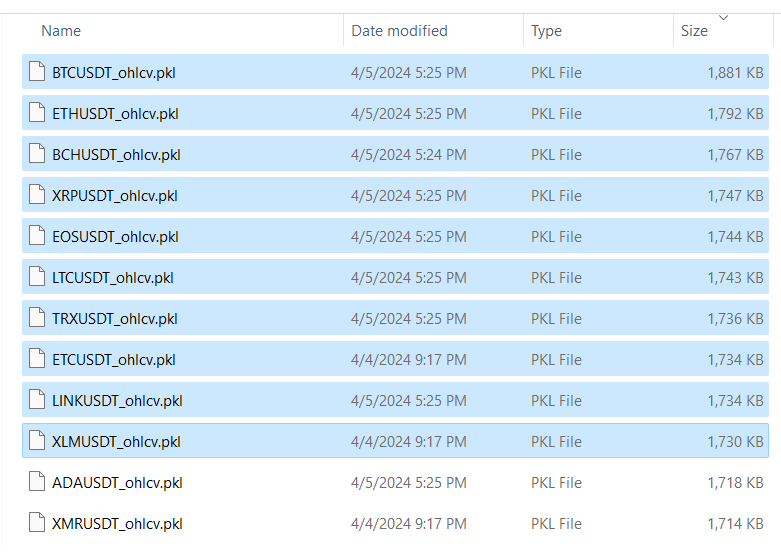

In [39]:
path_data_base = os.path.join(os.path.dirname(os.path.dirname(PROJECT_ROOT)), 'data_base')

symbol_list = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "SOLUSDT",
    "XRPUSDT",

    #"DOGEUSDT",
    #X"TONUSDT",

    "ADAUSDT",
    "AVAXUSDT",

    #X"1000SHIBUSDT",

    "TRXUSDT",
    "DOTUSDT",
    "LINKUSDT",
    # "MATICUSDT",
    # "LTCUSDT",
    #X"ICPUSDT",
    # "NEARUSDT",
    # "UNIUSDT",


    # "BCHUSDT",
    # "EOSUSDT",
    # "LTCUSDT",
    # "ETCUSDT",
    # "XLMUSDT",
]
df_open = pd.concat([
    pd.read_pickle(os.path.join(path_data_base, 'binance', 'usd', 'ohlcv', '1h', f"{symbol}_ohlcv.pkl"))[['open']]
    .rename(columns={'open': symbol})for symbol in symbol_list
], axis='columns').sort_index().ffill().dropna()

df_fr = pd.concat([
    pd.read_pickle(os.path.join(path_data_base, 'binance', 'usd', 'funding_rate', f"{symbol}_funding_rate.pkl"))[['funding_rate']]
    .rename(columns={'funding_rate': symbol})for symbol in symbol_list
], axis='columns').sort_index().ffill().dropna()

<Axes: xlabel='datetime'>

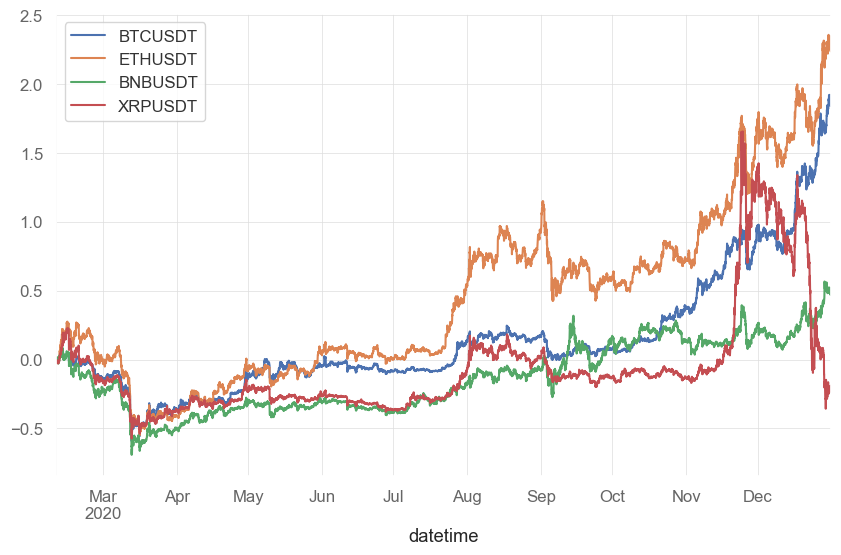

In [42]:
( (1+df_open.pct_change().dropna()[:'2020']).cumprod()-1).plot()

## Volume Distribution

In [263]:
df_volume = pd.concat([
    pd.read_pickle(os.path.join(path_data_base, 'binance', 'usd', 'ohlcv', '1h', f"{symbol}_ohlcv.pkl"))[['quote_asset_volume']]
    .rename(columns={'quote_asset_volume': symbol})for symbol in symbol_list
], axis='columns').sort_index().ffill().dropna()
df_volume = df_volume.tz_convert('US/Eastern')
df_volume['hour'] = df_volume.index.hour

In [ ]:
df_volume.set_index('hour').sum(axis='columns').groupby('hour').mean().plot(kind='bar')

In [ ]:
for col in symbol_list:
    df_volume.set_index('hour')[col].groupby('hour').mean().plot(kind='bar')
    plt.title(col)
    plt.show()

# Setting
* price select
    * backtest -> use open to match the datetime index
    * real -> use Symbol Price Ticker record (or open) to match the datetime index

* fr
    * ret_fr8
    * ( long )
        * = (o8 - o8*fr8) / o7 -1
        * = o8*(1-fr8) / o7 - 1
        * = o7 * (1+ret8) * (1-fr8) / o7 -1
        * = ret8 -fr8 - ret8*fr8
        * = ret8 - fr8 * ( 1 + ret8 )
    * ( short )
        * = o8*fr8 / o7 + ( -[ o8/o7 -1 ] )
        * = 1 - (o8 - o8*fr8)/o7 
        * = ( -long )

* fee
    * ret_fee2
    * ( long ) (o2 - o2*fee2) / o1 -1 = ret2 - fee2 * (1+ret2)
    * ( short ) 
        - = -[ o2/o1 -1 ] - o2*fee2 / o1
        - = -[ o2*(1+fee2) / o1 - 1 ]
        - = -[ (1+ret2)(1+fee2) -1 ] 
        - = -[ ret2 + fee2 + ret2fee2 ]
        - = -[ ret2 + fee2 * ( 1 + ret2 ) ]
        - = -[ ret2 ] - fee2 * (1+ret2)

* slippage ( same as fee for penalty ) 
    * ret_slip2
    * ( long ) 
        - = o2*(1-slip2) / o1 -1  =  (o2 - o2*slip2) / o1 -1 = ret2 - slip2 * (1+ret2)
        
    * ( short )
        - = -[ o2*(1+slip2) / o1 -1 ] = -[ ret2 ] - slip2 * (1+ret2) 

In [26]:
def get_daily_ret(ret):
    df = ret.copy()
    return (1 + df).resample('D').prod() - 1


def transform_position(value, one_side=4):
    if value <= one_side:
        return 1
    elif value >= len(symbol_list) - (one_side-1):
        return -1
    else:
        return 0


def get_weights_sharpe_rank(rets, periods=63, hold=8):
    sharpes = (rets.rolling(periods).mean() / rets.rolling(periods).std())
    sharpe_rank = sharpes.rank(axis=1, ascending=False).dropna()
    signals = sharpe_rank.map(transform_position, one_side=hold//2)
    weights = signals / hold
    return weights

def get_weights_ret_rank(df_open, periods=63, hold=8):
    rets = df_open.pct_change(periods=periods, fill_method=None).dropna()
    rets_rank = rets.rank(axis=1, ascending=False).dropna()
    signals = rets_rank.map(transform_position, one_side=hold//2)
    weights = signals / hold
    return weights

def get_weights_sharpe_ret(df_open, rets, period_sharpe_rank=51, period_ret_rank=64, hold=8):
    weights_sharpe = get_weights_sharpe_rank(rets=rets, periods=period_sharpe_rank, hold=hold)
    weights_ret = get_weights_ret_rank(df_open=df_open, periods=period_ret_rank, hold=hold)
    weights = (weights_sharpe + weights_ret)/2
    return weights


# MA
def get_weights_ma_rank(df_open, ma1=1, ma2=75, hold=8):
    p_ma1 = df_open.rolling(ma1).mean() if ma1 > 1 else df_open
    p_ma2 = df_open.rolling(ma2).mean()
    ma_pct_diff = p_ma1/p_ma2 -1
    ma_pct_diff_rank = ma_pct_diff.rank(axis=1, ascending=False).dropna()
    signals = ma_pct_diff_rank.map(transform_position, one_side=hold//2)
    weights = signals / hold
    return weights

def get_weights_sharpe_ret_ma(
        df_open, rets, hold=8,
        period_sharpe_rank=51, period_ret_rank=64, 
        ma1=1, ma2=75,
    ):
    weights_sharpe = get_weights_sharpe_rank(rets=rets, periods=period_sharpe_rank, hold=hold)
    weights_ret = get_weights_ret_rank(df_open=df_open, periods=period_ret_rank, hold=hold)
    weights_ma = get_weights_ma_rank(df_open=df_open, ma1=ma1, ma2=ma2, hold=hold)
    weights = (weights_sharpe + weights_ret + weights_ma)/3
    return weights



def get_ret_str(
        df_open, fr, hold=8, 
        period_sharpe_rank=51, period_ret_rank=64,
        ma1=1, ma2=75,
        fee=0.0005, slippage=0, 
        strategy='sharpe_ret_ma'
    ):
    # get weight
    rets = df_open.pct_change(fill_method=None).dropna()
    if strategy == 'sharpe_rank':
        weights = get_weights_sharpe_rank(rets=rets, periods=period_sharpe_rank, hold=hold)
    elif strategy == 'ret_rank':
        weights = get_weights_ret_rank(df_open, periods=period_ret_rank, hold=hold)
    elif strategy == 'sharpe_ret':
        weights = get_weights_sharpe_ret(
            df_open, rets, hold=hold,
            period_sharpe_rank=period_sharpe_rank, 
            period_ret_rank=period_ret_rank,
        )
    elif strategy == 'ma_rank':
        weights = get_weights_ma_rank(df_open, ma1=ma1, ma2=ma2, hold=hold)

    elif strategy == 'sharpe_ret_ma':
        weights = get_weights_sharpe_ret_ma(
            df_open, rets, hold=hold,
            period_sharpe_rank=period_sharpe_rank, 
            period_ret_rank=period_ret_rank,
            ma1=ma1, ma2=ma2,
        )

    # get ret
    # fr
    ret = weights.shift(1) * ( rets - fr * (1+rets) )                       # ret 計在下期

    #fee
    ret = ret - np.abs(weights.diff().fillna(0)) * ( fee * (1+ret) )        # fee 計在轉倉當下

    # slippage
    ret = ret - np.abs(weights.diff().fillna(0)) * ( slippage * (1+ret) )   # slippage 計在轉倉當下
    return ret


# Test

In [ ]:
def rank_adj_ma(df_price, periods, shift_periods=0):
    adj_ma = (df_price.rolling(periods).mean()/df_price).shift(shift_periods).dropna()
    return adj_ma.rank(axis='columns', ascending=False)


def rank_er_trend(df_price, periods, shift_periods=0):

    df = pd.DataFrame({'close_adj':df_price.stack()})
    df.index.names = ['datetime', 'symbol']
    df['ret'] = df['close_adj'].unstack().pct_change(fill_method=None).stack(future_stack=True).dropna()

    window_short,window_long = 100, 400 

    p_d = df['close_adj'].unstack()#.resample('D').last()
    ma100_p = df['close_adj'].unstack().rolling(window_short).mean()#.resample('D').last()
    ma400_p = df['close_adj'].unstack().rolling(window_long).mean()#.resample('D').last()
    ret_d = (df['ret']).unstack()#.resample('D').prod() - 1
    ma100_p_tilde = ma100_p / p_d
    ma400_p_tilde = ma400_p / p_d

    df = pd.DataFrame({
        'ret_d':ret_d.stack(future_stack=True).dropna(),
        'ma100_p_tilde':ma100_p_tilde.stack(future_stack=True).dropna(),
        'ma400_p_tilde':ma400_p_tilde.stack(future_stack=True).dropna(),
    }).dropna()


    # cross-sectional regression
    date_li = df.droplevel(1).index.unique()

    result_li=[]
    for date in tqdm.tqdm(date_li):
        # Subset the DataFrame to the current date
        df_date = df.loc[date].dropna().copy()
        y = df_date['ret_d']
        X = df_date[df.columns[1:]]
        X = sm.add_constant(X)
        # Perform the OLS regression
        model = sm.OLS(y, X).fit()
        result_li.append(pd.DataFrame({date:model.params}))
    df_Bi = (pd.concat(result_li, axis='columns').T).iloc[:, 1:]
    df_Bi.columns = [f"B{i}" for i in range(1, 2+1)]
    df = df[df.columns[1:]]
    df.columns = [f"ma_tilde{i}" for i in range(1, 2+1)]


    # E(B)
    er_trend_dic = {}
    er_trend_li = []
    expanding_sharpe_dic = {}

    for i in tqdm.tqdm(range(1, 100+1)):
        alpha = i/100
        er_trend_i = 0
        er_trend = 0
        e_Bi = df_Bi.ewm(
                alpha = alpha, 
                min_periods = 0, 
                adjust = False, 
                ignore_na = False
            ).mean()
        for i in range(1, 2+1):
            er_trend_i += (df[f"ma_tilde{i}"].unstack().multiply(e_Bi[f"B{i}"], axis='rows'))
            er_trend += er_trend_i.mean(axis='columns')

        df_er_trend = pd.DataFrame({'er_trend':er_trend_i.stack()})
        df_er_trend['alpha'] = alpha
        er_trend_li.append(df_er_trend)   
        er_trend_dic[alpha] = er_trend

        expanding_mean = er_trend.expanding().mean()
        expanding_std = er_trend.expanding().std()
        expanding_sharpe = expanding_mean / expanding_std
        expanding_sharpe_dic[alpha] = expanding_sharpe

    er_trend_i_df = pd.concat(er_trend_li, axis='rows')  
    er_trend_df = pd.DataFrame(er_trend_dic) 
    expanding_sharpe_df = pd.DataFrame(expanding_sharpe_dic)


    # ER_Trend
    df = er_trend_i_df.copy()
    best_alpha = expanding_sharpe_df.idxmax(axis='columns', skipna=True).shift(1)
    df = df.reset_index().set_index(['datetime'])
    df['best_alpha'] = best_alpha
    df = df[df['best_alpha'].isna()==False].reset_index().set_index(['datetime', 'symbol'])
    index_col = df.index.names
    df = df.reset_index().drop_duplicates(subset=index_col, keep='last').set_index(index_col)
    er_trend = df['er_trend'].dropna().unstack()

    return er_trend.rank(axis='columns', ascending=False).shift(shift_periods)

# Backtest
* fee = 0.0005
* flippage = 0


## Opti

In [43]:
df_open[:'2020-3-31'].shape[0]//8

152

In [44]:
# from concurrent.futures import ProcessPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import cpu_count, Pool
from math import floor
import seaborn as sns

cores_to_use = floor(cpu_count()  * 0.5)
processes_to_use = max(1, os.cpu_count() // 2)

start = '2020-4-1 00:00:00 +0000'  #'2020-12'
in_end = df_open[start:].index[int(len(df_open[start:].index)*0.7)]
in_end

Timestamp('2023-02-01 02:00:00+0000', tz='UTC')

In [ ]:
((1+df_open[start:in_end].pct_change()).cumprod()-1).plot()

In [18]:
def get_perf_1param(
        df_open, df_fr, 
        periods=63, hold=8, 
        strategy='sharpe_rank',
        start=start, end=in_end, annual_factor=365.25, 
    ):
    ret_bt = get_ret_str(
        df_open, df_fr, hold = hold,
        periods = periods,
        strategy = strategy,
    )[start:end].sum(axis='columns')

    perf = bt.perf_table(get_daily_ret(ret_bt), annual_factor=annual_factor, is_compound=True)
    perf.insert(1, 'periods', periods)
    return perf


def get_perf_2param(
        df_open, df_fr, 
        ma1=15, ma2=30, hold=8, 
        strategy='ma_rank',
        start=start, end=in_end, annual_factor=365.25,     
    ):
    ret_bt = get_ret_str(
        df_open, df_fr, hold = hold,
        ma1=ma1, ma2=ma2, 
        strategy = strategy,
    )[start:end].sum(axis='columns')

    perf = bt.perf_table(get_daily_ret(ret_bt), annual_factor=annual_factor, is_compound=True)
    perf.insert(1, 'ma2', ma2)
    perf.insert(1, 'ma1', ma1)
    return perf



def get_perf_concat(
        df_open, df_fr, 
        hold=8, period_sharpe_rank=51, period_ret_rank=64,
        start=start, end=in_end, annual_factor=365.25, strategy='sharpe_rank'
    ):
    ret_bt = get_ret_str(
        df_open, df_fr, hold = hold,
        period_sharpe_rank=period_sharpe_rank, period_ret_rank=period_ret_rank,
        strategy = strategy,
    )[start:end].sum(axis='columns')

    perf = bt.perf_table(get_daily_ret(ret_bt), annual_factor=annual_factor, is_compound=True)
    perf.insert(1, 'period_ret_rank', period_ret_rank)
    perf.insert(1, 'period_sharpe_rank', period_sharpe_rank)
    return perf

In [ ]:
# ma_rank
timeframe = '8h'
max_param, gap = 152, 1
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
param_list = [
    (i, j) for i in range(1, max_param+1, gap) for j in range(1, max_param+1, gap) if i<j
]
hold_li = [2]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_2param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            ma1=ma1, ma2=ma2,
            hold = hold,
            strategy = 'ma_rank'
        ) for ma1, ma2 in param_list)
    perf_df = pd.concat(perf_li, axis='rows').set_index(['ma1', 'ma2'])
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

In [ ]:
plt.subplots(figsize=(12, 5))
sns.heatmap(perf_df['CAGR(%)'].unstack())
plt.show()

plt.subplots(figsize=(12, 5))
sns.heatmap(perf_df['MDD(%)'].dropna().unstack())
plt.show()

plt.subplots(figsize=(12, 5))
sns.heatmap(perf_df['Annual_Sharpe'].dropna().unstack())
plt.show()

In [ ]:
[df_open.index.hour==15]

In [49]:
# ma_rank -> 7, 34
timeframe = '8h'
max_param, gap = 152, 1
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
param_list = [
    (i, j) for i in [1] for j in range(1, max_param+1, gap) if i<j
]
hold_li = [2]#, 4, 6, 8]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_2param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            ma1=ma1, ma2=ma2,
            hold = hold,
            strategy = 'ma_rank'
        ) for ma1, ma2 in param_list)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index(['ma1', 'ma2'])
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

,CAGR(%),MDD(%),Annual_Sharpe
0.75,85.52189,-30.249288,1.46114


,CAGR(%),MDD(%),Annual_Sharpe
0.75,85.862451,-30.241805,1.464261


name                     None
Total_Return(%)    484.212849
CAGR(%)             82.672422
Annual_Sharpe        1.421983
Annual_Vol           0.512945
MDD(%)             -30.234321
max_dd_period            -337
Ret_to_Vol           9.439854
Ret_to_MDD          16.015337
CAGR_to_Vol           1.61172
CAGR_to_MDD           2.73439
profit_to_loss       1.160939
Win_Rate(%)         49.285033
Name: 64, dtype: object

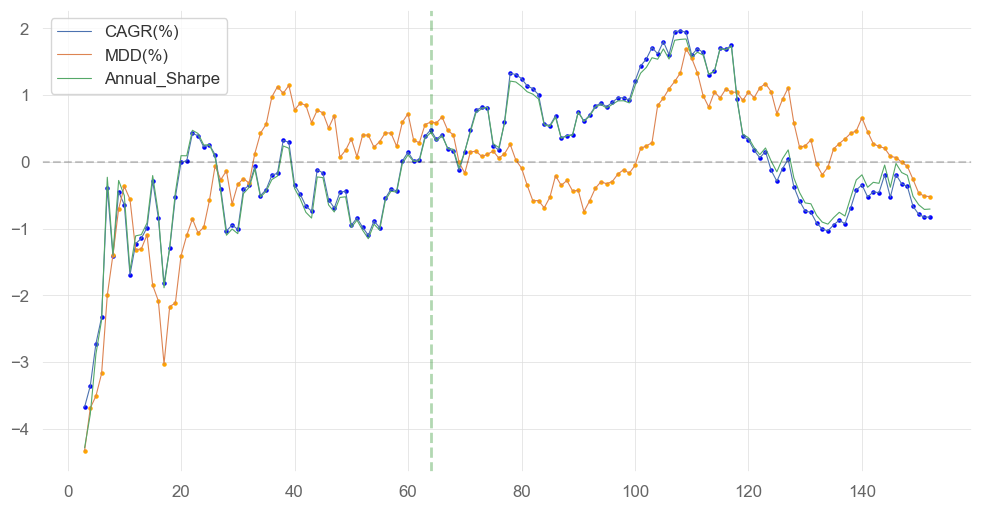

In [50]:
# ma_rank -> 7, 34
timeframe = '8h'
max_param, gap = 152, 1
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
param_list = [
    (i, j) for i in [1] for j in range(3, max_param+1, gap) if i<j
]
hold_li = [2]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_2param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            ma1=ma1, ma2=ma2,
            hold = hold,
            strategy = 'ma_rank'
        ) for ma1, ma2 in param_list)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index(['ma1', 'ma2']).droplevel(0)
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

    choose_param = 64
    display(perf_df.loc[choose_param])
    perf_z = (perf_df[need_perf] - perf_df[need_perf].mean()) / perf_df[need_perf].std()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot( perf_z , label=need_perf, linewidth=0.8)
    ax.scatter(perf_z.index, perf_z[need_perf[0]], color='blue', s=5)
    ax.scatter(perf_z.index, perf_z[need_perf[1]], color='orange', s=5)
    ax.axvline(choose_param, color='green', linestyle='--', alpha=0.3, linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.2)
    plt.legend()
    plt.show()

In [52]:
# ret_rank
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)

period_li = range(3, 152*1+1) #89, 122
hold_li = [2]#, 4, 6, 8]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_1param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'ret_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

,CAGR(%),MDD(%),Annual_Sharpe
0.75,71.593463,-37.066363,1.316615


,CAGR(%),MDD(%),Annual_Sharpe
0.75,71.593463,-37.066363,1.316615


name                     None
Total_Return(%)    371.840164
CAGR(%)             69.825677
Annual_Sharpe        1.280747
Annual_Vol           0.512522
MDD(%)             -33.578657
max_dd_period            -481
Ret_to_Vol           7.255105
Ret_to_MDD          11.073706
CAGR_to_Vol          1.362393
CAGR_to_MDD          2.079466
profit_to_loss       1.143434
Win_Rate(%)         49.717514
Name: 24, dtype: object

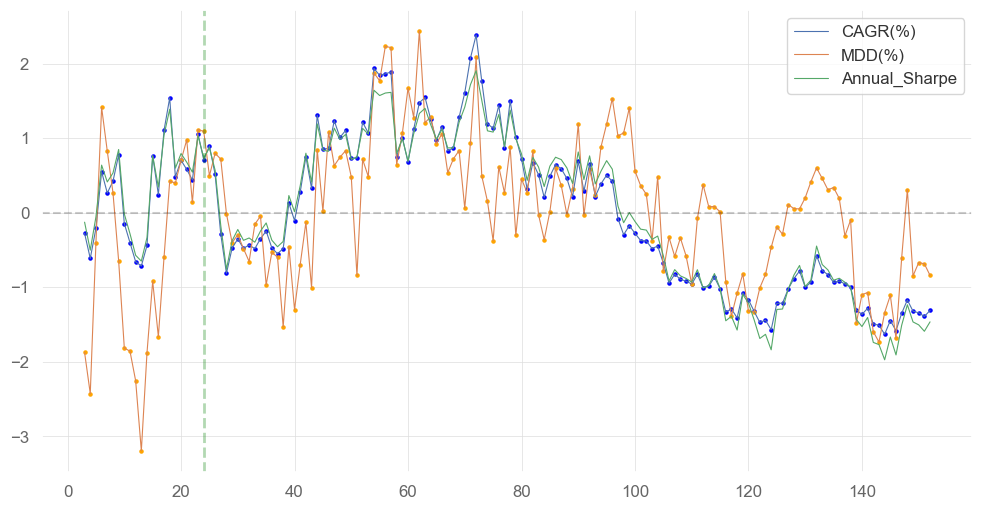

In [54]:
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
period_li = range(3, 152+1) #89, 122
hold_li = [2]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_1param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'ret_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))


    choose_param = 24
    display(perf_df.loc[choose_param])
    perf_z = (perf_df[need_perf] - perf_df[need_perf].mean()) / perf_df[need_perf].std()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot( perf_z , label=need_perf, linewidth=0.8)
    ax.scatter(perf_z.index, perf_z[need_perf[0]], color='blue', s=5)
    ax.scatter(perf_z.index, perf_z[need_perf[1]], color='orange', s=5)
    ax.axvline(choose_param, color='green', linestyle='--', alpha=0.3, linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.2)
    plt.legend()
    plt.show()

In [55]:
# sharpe_rank
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)

period_li = range(3, 152*1+1) #89, 122
hold_li = [2]#, 4, 6, 8]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_1param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'sharpe_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

,CAGR(%),MDD(%),Annual_Sharpe
0.75,61.660481,-39.40126,1.219454


,CAGR(%),MDD(%),Annual_Sharpe
0.75,61.660481,-39.40126,1.219454


name                    None
Total_Return(%)    445.57736
CAGR(%)            78.455402
Annual_Sharpe       1.395739
Annual_Vol          0.502507
MDD(%)            -35.304632
max_dd_period           -450
Ret_to_Vol          8.867087
Ret_to_MDD         12.620932
CAGR_to_Vol          1.56128
CAGR_to_MDD         2.222241
profit_to_loss      1.183113
Win_Rate(%)         49.85755
Name: 50, dtype: object

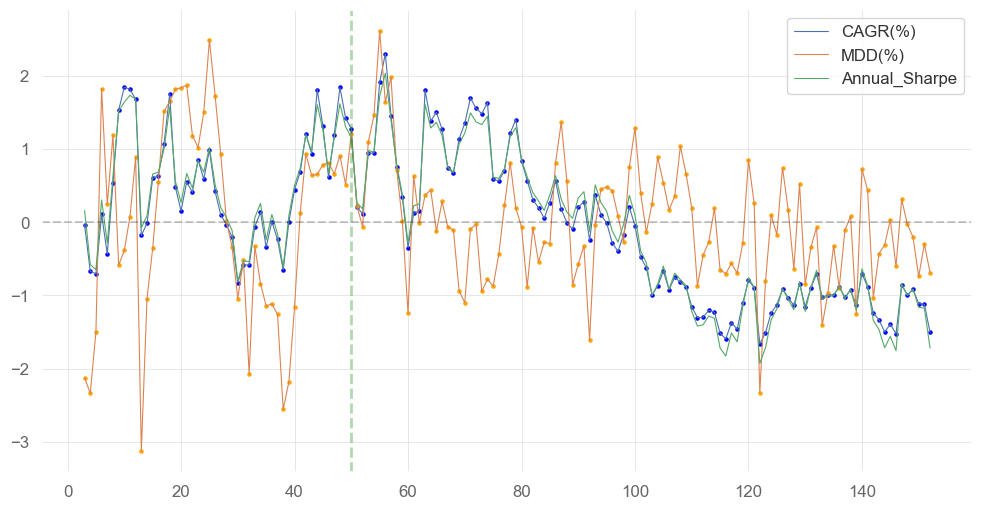

In [56]:
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
period_li = range(3, 152+1) #89, 122
hold_li = [2]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf_1param)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'sharpe_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))


    choose_param = 50
    display(perf_df.loc[choose_param])
    perf_z = (perf_df[need_perf] - perf_df[need_perf].mean()) / perf_df[need_perf].std()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot( perf_z , label=need_perf, linewidth=0.8)
    ax.scatter(perf_z.index, perf_z[need_perf[0]], color='blue', s=5)
    ax.scatter(perf_z.index, perf_z[need_perf[1]], color='orange', s=5)
    ax.axvline(choose_param, color='green', linestyle='--', alpha=0.3, linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.2)
    plt.legend()
    plt.show()

### 15:00

In [58]:
# ret_rank
timeframe = '8h'
open_timeframe = df_open[df_open.index.hour==15].resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)

period_li = range(3, 113*1+1) #89, 122
hold_li = [2, 4, 6, 8]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'ret_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

,CAGR(%),MDD(%),Annual_Sharpe
0.75,91.899747,-37.970986,1.271197


,CAGR(%),MDD(%),Annual_Sharpe
0.75,78.259946,-28.30158,1.489505


,CAGR(%),MDD(%),Annual_Sharpe
0.75,62.395218,-20.650559,1.556463


,CAGR(%),MDD(%),Annual_Sharpe
0.75,69.192997,-18.857115,1.878535


In [71]:
# sharpe_rank
timeframe = 'D'
open_timeframe = df_open[df_open.index.hour==15].resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)

period_li = range(3, 37*1+1) #89, 122
hold_li = [2, 4, 6, 8]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'sharpe_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))

,CAGR(%),MDD(%),Annual_Sharpe
0.75,59.086199,-19.151484,1.741407


,CAGR(%),MDD(%),Annual_Sharpe
0.75,68.291874,-19.441328,1.861525


name                     None
Total_Return(%)    323.001164
CAGR(%)             81.709587
Annual_Sharpe        2.082749
Annual_Vol           0.309695
MDD(%)             -17.378796
max_dd_period            -292
Ret_to_Vol          10.429641
Ret_to_MDD          18.585934
CAGR_to_Vol          2.638386
CAGR_to_MDD          4.701683
profit_to_loss       1.247617
Win_Rate(%)         52.440409
Name: 64, dtype: object

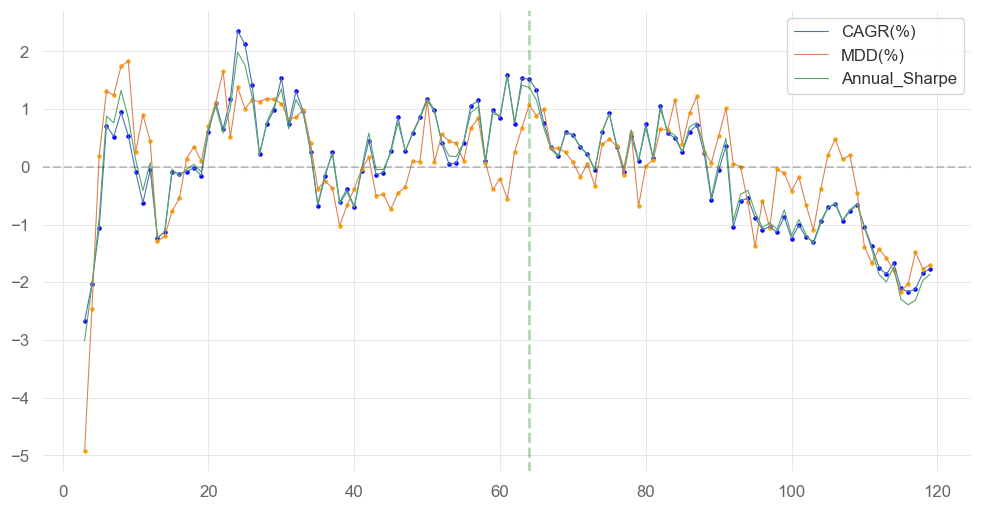

In [61]:
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
period_li = range(3, 119+1) #89, 122
hold_li = [8]

for hold in hold_li:
    with Parallel(n_jobs=cores_to_use) as parallel:
        perf_li = parallel(delayed(get_perf)(
            df_open = open_timeframe,
            df_fr = fr_timeframe,
            periods = periods, 
            hold = hold,
            strategy = 'ret_rank'
        ) for periods in period_li)#, hold) for periods, hold in zip(period_li, hold_li))
    perf_df = pd.concat(perf_li, axis='rows').set_index('periods')
    need_perf = ['CAGR(%)', 'MDD(%)', 'Annual_Sharpe']
    display(perf_df[need_perf].quantile([0.75]))


    choose_param = 64
    display(perf_df.loc[choose_param])
    perf_z = (perf_df[need_perf] - perf_df[need_perf].mean()) / perf_df[need_perf].std()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot( perf_z , label=need_perf, linewidth=0.8)
    ax.scatter(perf_z.index, perf_z[need_perf[0]], color='blue', s=5)
    ax.scatter(perf_z.index, perf_z[need_perf[1]], color='orange', s=5)
    ax.axvline(choose_param, color='green', linestyle='--', alpha=0.3, linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.2)
    plt.legend()
    plt.show()

## Result
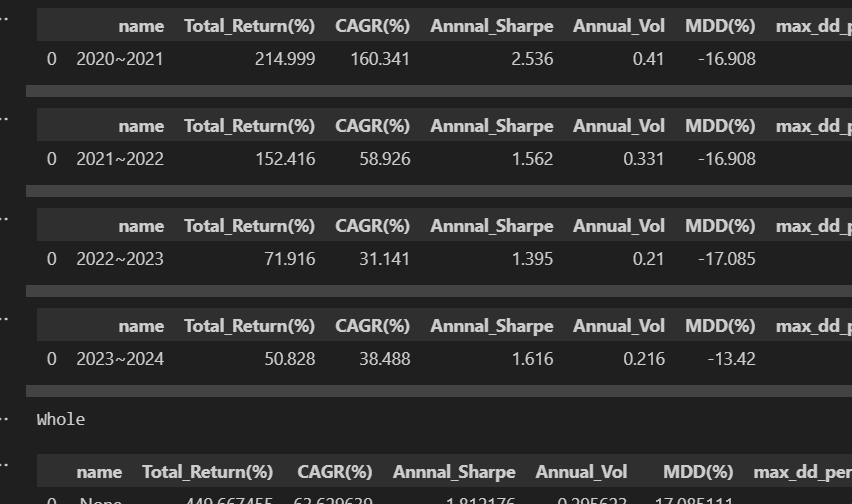

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,41.605,12.268,0.928,0.134,-11.4,-474,3.095,3.649,0.913,1.076,1.14,51.413


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,61.249,17.277,0.944,0.187,-17.0,-469,3.267,3.603,0.922,1.016,1.133,53.382


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,0.742,0.247,0.079,0.115,-16.732,-514,0.064,0.044,0.021,0.015,1.005,47.989


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,-18.723,-6.681,-0.911,0.073,-19.542,-1061,-2.567,-0.958,-0.916,-0.342,0.863,49.909


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,-3.349,-3.689,-0.307,0.105,-12.085,-304,-0.32,-0.277,-0.353,-0.305,0.948,51.515


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,80.70216,4.691163,0.413048,0.132187,-38.64157,-1613,6.105148,2.08848,0.354888,0.121402,1.041628,50.732018


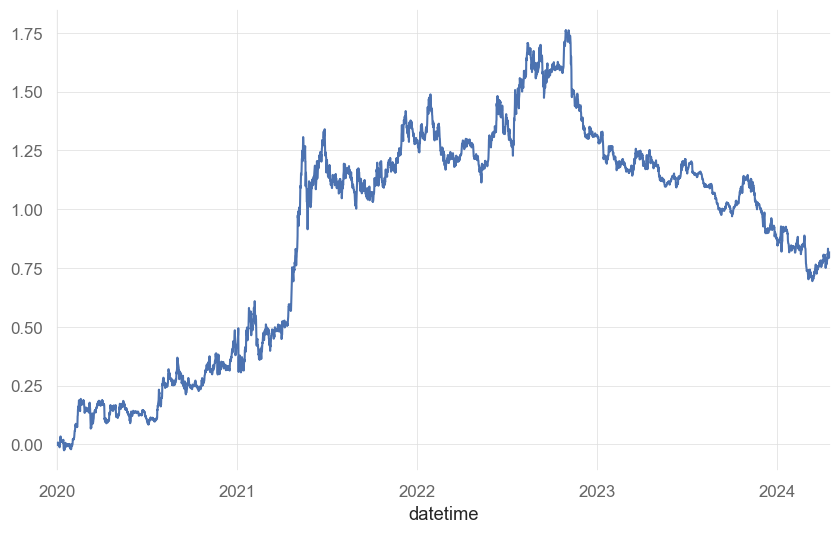

In [35]:
# ma_rank -> 7, 34
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
annual_factor = 365.25

ret = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    ma1=1, ma2=100,
    hold = 2,
    strategy = 'ma_rank'
).dropna().sum(axis='columns')
((1+ret).cumprod()-1).plot()

bt.get_rolling_perf(ret=ret, year=1, lev=1, annual_factor=annual_factor, is_compound=True)

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,66.279,18.43,1.328,0.134,-13.815,-301,4.941,4.798,1.374,1.334,1.209,52.78


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,45.852,13.416,0.765,0.188,-24.354,-692,2.444,1.883,0.715,0.551,1.103,53.108


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,15.529,4.933,0.477,0.115,-12.458,-421,1.355,1.246,0.431,0.396,1.065,48.537


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,-7.738,-2.651,-0.334,0.072,-11.114,-1010,-1.067,-0.696,-0.366,-0.238,0.943,52.011


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,1.826,2.017,0.243,0.104,-9.097,-282,0.175,0.201,0.193,0.222,1.033,52.424


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,163.222418,7.787263,0.63451,0.131937,-24.354252,-1847,12.371262,6.702009,0.590227,0.31975,1.074318,51.665606


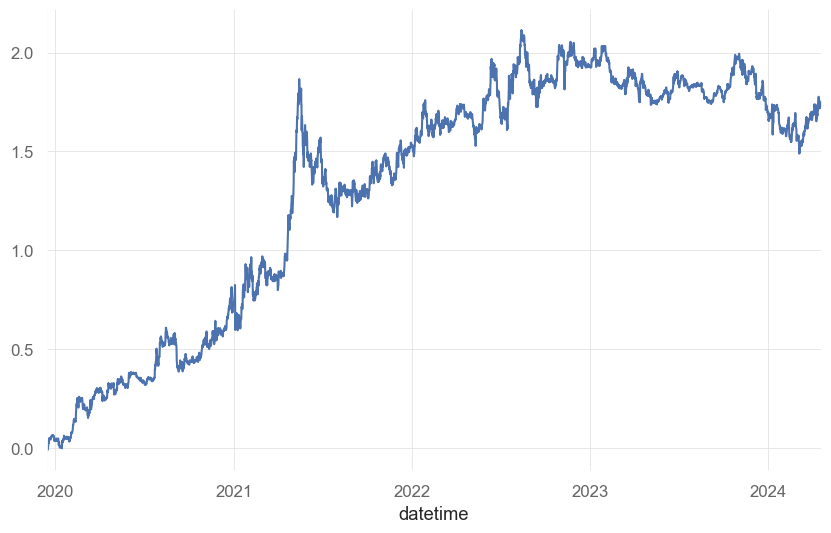

In [36]:
# ret_rank
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
annual_factor = 365.25
ret = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    periods = 50,
    hold = 2,
    strategy = 'ret_rank'
).dropna().sum(axis='columns')
((1+ret).cumprod()-1).plot()

bt.get_rolling_perf(ret=ret, year=1, lev=1, annual_factor=annual_factor, is_compound=True)

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,57.183,16.234,1.188,0.134,-15.792,-474,4.26,3.621,1.209,1.028,1.193,52.78


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,33.987,10.251,0.614,0.188,-19.405,-692,1.812,1.751,0.546,0.528,1.081,51.828


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,19.742,6.194,0.582,0.114,-15.553,-480,1.724,1.269,0.541,0.398,1.088,49.543


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,-7.944,-2.723,-0.346,0.072,-13.981,-833,-1.1,-0.568,-0.377,-0.195,0.944,52.468


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,4.505,4.983,0.519,0.104,-7.091,-210,0.432,0.635,0.478,0.703,1.078,52.424


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,142.609168,7.10836,0.586859,0.131872,-19.405412,-1288,10.8142,7.348938,0.539034,0.366308,1.07379,51.686824


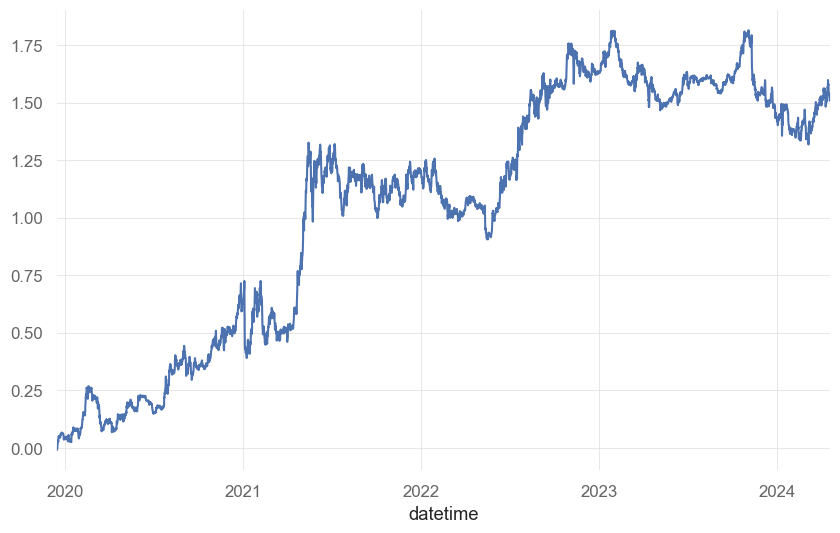

In [38]:
# sharpe_rank
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
annual_factor = 365.25
ret = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    periods = 50,
    hold = 2,
    strategy = 'sharpe_rank'
).dropna().sum(axis='columns')
((1+ret).cumprod()-1).plot()

bt.get_rolling_perf(ret=ret, year=1, lev=1, annual_factor=annual_factor, is_compound=True)

## 合併

In [8]:
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
annual_factor = 365.25

hold = 8
period_sharpe_rank = 51 
period_ret_rank = 64
ma1, ma2 = 1, 75
max_param = max(period_sharpe_rank, period_ret_rank)
max_param2 = max(period_sharpe_rank, period_ret_rank, ma2)

# ret_rank
ret1 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    periods = period_sharpe_rank,
    hold = hold,
    strategy = 'sharpe_rank'
).sum(axis='columns').iloc[max_param+2:]

# sharpe_rank
ret2 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    periods = period_ret_rank,
    hold = hold,
    strategy = 'ret_rank'
).sum(axis='columns').iloc[max_param+2:]

## concat -> 改調整權重進行
# ret = pd.concat([ret1, ret2], axis='columns').fillna(0).mean(axis='columns').sort_index()

# Equal Weight
ret = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    hold=hold,
    period_sharpe_rank=period_sharpe_rank, 
    period_ret_rank=period_ret_rank,
    strategy = 'sharpe_ret',
).sum(axis='columns').iloc[max_param+2:]


ret3 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    ma1=ma1, ma2=ma2,
    hold = 8,
    strategy = 'ma_rank'
).dropna().sum(axis='columns')



ret_concat3 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    hold=hold,
    period_sharpe_rank=period_sharpe_rank, 
    period_ret_rank=period_ret_rank,
    ma1=ma1, ma2=ma2,
    strategy = 'sharpe_ret_ma',
).sum(axis='columns').iloc[max_param2+2:]

<Axes: xlabel='datetime'>

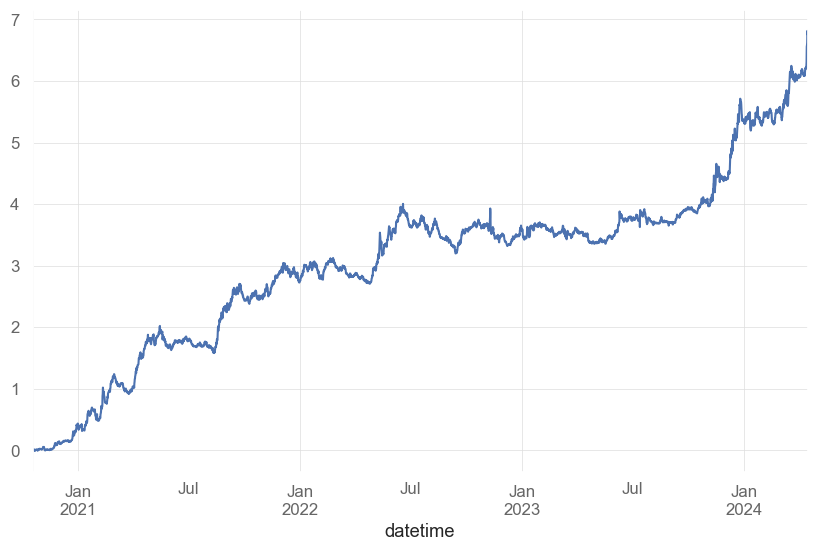

In [9]:
((1+ret_concat3).cumprod()-1).plot()

In [10]:
pd.DataFrame({'sharpe':ret1, 'ret':ret2, 'ma':ret3}).corr()

,sharpe,ret,ma
sharpe,1.000000,0.760461,0.785699
ret,0.760461,1.000000,0.880362
ma,0.785699,0.880362,1.000000


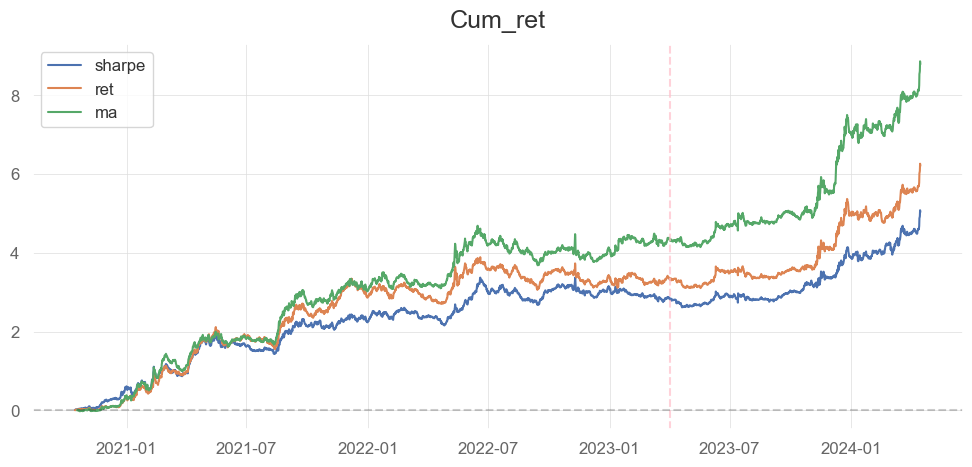

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( (1+ret1[:]).cumprod()-1, label='sharpe')
ax.plot( (1+ret2[:]).cumprod()-1, label='ret')
ax.plot( (1+ret3[:]).cumprod()-1, label='ma')
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret', fontsize=18, y=1.02)
plt.show()


In [13]:
bt.get_rolling_perf(ret=ret_concat3, year=1, lev=4.5, annual_factor=annual_factor, is_compound=True)

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,330.567,122299.65,5.531,1.482,-22.748,-18,2.23,14.531,825.018,5376.199,2.583,60.811


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,2894.936,2901.918,2.911,1.579,-53.852,-97,18.333,53.757,18.377,53.887,1.283,56.319


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,70.264,70.326,1.043,0.938,-53.424,-196,0.749,1.315,0.75,1.316,1.07,51.374


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,239.567,239.852,1.876,0.831,-30.5,-138,2.883,7.855,2.886,7.864,1.376,50.549


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,122.718,1520.67,3.333,0.981,-18.763,-24,1.251,6.54,15.498,81.044,1.665,56.731


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,186115.654712,764.496941,2.382082,1.191642,-55.231875,-510,1561.842503,3369.714566,6.415494,13.841589,1.375368,53.21821


In [38]:
bt.get_rolling_perf(ret=ret1, year=1, lev=6, annual_factor=annual_factor, is_compound=True)

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,1117.815,1.044940e+07,6.831,1.985,-27.885,-16,5.631,40.086,52637.72,374730.313,2.959,62.821


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,995.031,996.828,2.133,2.165,-72.485,-116,4.595,13.727,4.603,13.752,1.143,53.571


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,112.518,112.628,1.241,1.172,-65.756,-195,0.96,1.711,0.961,1.713,1.069,51.923


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,96.149,96.24,1.16,1.02,-58.412,-306,0.942,1.646,0.943,1.648,1.171,52.198


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,189.824,3951.05,3.304,1.437,-26.29,-41,1.321,7.22,27.494,150.286,1.669,55.769


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,171019.309973,738.201229,2.088998,1.598336,-75.667756,-550,1069.983653,2260.134555,4.618562,9.755823,1.261191,52.738654


In [30]:
year, lev = 1, 1

for i in range(int(ret.index[0].year), 2024-year+2):
    perf_df = pd.concat([
        bt.perf_table(
            bt.get_daily_ret(ret1[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'sharpe_rank'
        ).round(3),
        bt.perf_table(
            bt.get_daily_ret(ret2[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'ret_rank'
        ).round(3),
        bt.perf_table(
            bt.get_daily_ret(ret[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'equal_weight2'
        ).round(3),
        bt.perf_table(
            bt.get_daily_ret(ret_concat3[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'equal_weight3'
        ).round(3),
        bt.perf_table(
            bt.get_daily_ret(ret3[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'ma_rank'
        ).round(3),
    ], axis='rows')
    perf_df['year'] = f'{i}~{i+year-1}'
    display(perf_df.set_index(['year', 'name']))

perf_df = pd.concat([
    bt.perf_table(
        bt.get_daily_ret(ret1)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'sharpe_rank'
    ).round(3),
    bt.perf_table(
        bt.get_daily_ret(ret2)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'ret_rank'
    ).round(3),
    bt.perf_table(
        bt.get_daily_ret(ret)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'equal_weight'
    ).round(3),
    bt.perf_table(
        bt.get_daily_ret(ret_concat3)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'equal_weight3'
    ).round(3),
    bt.perf_table(
        bt.get_daily_ret(ret3)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'ma_rank'
    ).round(3),
], axis='rows')
perf_df['year'] = 'whole'
display(perf_df.set_index(['year', 'name']))

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                                 
2020~2020 sharpe_rank             60.946  802.753          6.831       0.331   
          ret_rank                35.833  312.042          4.370       0.337   
          equal_weight2           48.098  514.489          5.802       0.322   
          equal_weight3           43.679  484.119          5.531       0.329   
          ma_rank                 38.173  382.897          4.854       0.336   

                         MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                           
2020~2020 sharpe_rank    -5.018            -15       1.842      12.145   
          ret_rank       -5.676            -18       1.062       6.314   
          equal_weight2  -5.162            -17       1.492       9.318   
          equal_weight3  -5.356            -18       1.326       8.155   
          ma_rank        -5.857            -18       1.135       6.518   

                         CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                  
2020~2020 sharpe_rank         24.263      159.962           2.903       62.821  
          ret_rank             9.250       54.981           2.015       57.692  
          equal_weight2       15.957       99.671           2.524       64.103  
          equal_weight3       14.696       90.391           2.492       60.811  
          ma_rank             11.383       65.378           2.246       59.459

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                                 
2021~2021 sharpe_rank            102.283  102.381          2.133       0.361   
          ret_rank               186.082  186.288          2.957       0.380   
          equal_weight2          143.501  143.649          2.730       0.348   
          equal_weight3          160.969  161.140          2.911       0.351   
          ma_rank                193.130  193.346          2.988       0.385   

                         MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                           
2021~2021 sharpe_rank   -17.218           -104       2.834       5.940   
          ret_rank      -17.379            -97       4.895      10.707   
          equal_weight2 -17.013           -101       4.118       8.435   
          equal_weight3 -14.594            -97       4.587      11.029   
          ma_rank       -17.646            -93       5.016      10.945   

                         CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                  
2021~2021 sharpe_rank          2.837        5.946           1.345       53.571  
          ret_rank             4.900       10.719           1.491       55.495  
          equal_weight2        4.122        8.444           1.475       53.571  
          equal_weight3        4.592       11.041           1.513       56.319  
          ma_rank              5.022       10.957           1.520       55.769

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                                 
2022~2022 sharpe_rank             25.005   25.024          1.241       0.195   
          ret_rank                11.938   11.946          0.613       0.225   
          equal_weight2           19.238   19.252          0.991       0.197   
          equal_weight3           21.585   21.601          1.043       0.208   
          ma_rank                 24.437   24.456          1.016       0.245   

                         MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                           
2022~2022 sharpe_rank   -14.817           -142       1.280       1.688   
          ret_rank      -15.884           -201       0.530       0.752   
          equal_weight2 -14.711           -142       0.975       1.308   
          equal_weight3 -14.745           -143       1.036       1.464   
          ma_rank       -15.876           -199       0.999       1.539   

                         CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                  
2022~2022 sharpe_rank          1.281        1.689           1.169       51.923  
          ret_rank             0.530        0.752           1.076       50.275  
          equal_weight2        0.976        1.309           1.135       51.374  
          equal_weight3        1.036        1.465           1.147       51.374  
          ma_rank              0.999        1.540           1.143       50.824

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                                 
2023~2023 sharpe_rank             20.046   20.061          1.160       0.170   
          ret_rank                37.318   37.348          1.646       0.206   
          equal_weight2           29.160   29.183          1.544       0.176   
          equal_weight3           38.979   39.010          1.876       0.185   
          ma_rank                 59.014   59.064          2.257       0.216   

                         MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                           
2023~2023 sharpe_rank   -12.389           -284       1.179       1.618   
          ret_rank       -8.353           -126       1.815       4.467   
          equal_weight2  -8.723           -151       1.659       3.343   
          equal_weight3  -7.013           -137       2.111       5.558   
          ma_rank        -5.828            -89       2.733      10.125   

                         CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                  
2023~2023 sharpe_rank          1.180        1.619           1.191       52.198  
          ret_rank             1.817        4.471           1.301       49.725  
          equal_weight2        1.660        3.346           1.278       50.000  
          equal_weight3        2.112        5.563           1.357       50.549  
          ma_rank              2.735       10.134           1.454       52.198

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                                 
2024~2024 sharpe_rank             24.497  114.297          3.304       0.240   
          ret_rank                21.611   97.510          3.200       0.220   
          equal_weight2           23.261  106.989          3.445       0.218   
          equal_weight3           23.320  107.331          3.419       0.220   
          ma_rank                 23.106  106.082          3.208       0.234   

                         MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                           
2024~2024 sharpe_rank    -4.553            -25       1.023       5.381   
          ret_rank       -5.717            -42       0.981       3.780   
          equal_weight2  -3.866            -24       1.066       6.016   
          equal_weight3  -4.242            -24       1.058       5.498   
          ma_rank        -5.003            -22       0.987       4.618   

                         CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                  
2024~2024 sharpe_rank          4.772       25.106           1.647       55.769  
          ret_rank             4.425       17.055           1.576       59.615  
          equal_weight2        4.902       27.672           1.644       55.769  
          equal_weight3        4.868       25.304           1.647       56.731  
          ma_rank              4.531       21.202           1.620       61.538

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year  name                                                                 
whole sharpe_rank            508.235   67.460          2.104       0.261   
      ret_rank               626.397   76.169          2.153       0.281   
      equal_weight           584.571   73.211          2.278       0.255   
      equal_weight3          681.339   80.207          2.387       0.261   
      ma_rank                886.614   92.661          2.404       0.290   

                     MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year  name                                                           
whole sharpe_rank   -17.218           -370      19.451      29.517   
      ret_rank      -17.379           -515      22.268      36.044   
      equal_weight  -17.013           -366      22.880      34.361   
      equal_weight3 -14.745           -324      26.097      46.209   
      ma_rank       -17.646           -358      30.532      50.245   

                     CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year  name                                                                  
whole sharpe_rank          2.582        3.918           1.313       53.443  
      ret_rank             2.708        4.383           1.324       52.895  
      equal_weight         2.865        4.303           1.353       52.739  
      equal_weight3        3.072        5.440           1.385       53.532  
      ma_rank              3.191        5.251           1.403       54.003

In [16]:
year, lev = 1, 1

for i in range(int(ret.index[0].year), 2024-year+2):
    perf_df = pd.concat([
        bt.perf_table(
            bt.get_daily_ret(ret1[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'sharpe_rank'
        ).round(3),
        bt.perf_table(
            bt.get_daily_ret(ret2[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'ret_rank'
        ).round(3),
        bt.perf_table(
            bt.get_daily_ret(ret3[str(i):str(i+year-1)])*lev, 
            annual_factor=annual_factor, 
            is_compound=True, 
            name = 'ma_rank'
        ).round(3),
    ], axis='rows')
    perf_df['year'] = f'{i}~{i+year-1}'
    display(perf_df.set_index(['year', 'name']))

perf_df = pd.concat([
    bt.perf_table(
        bt.get_daily_ret(ret1)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'sharpe_rank'
    ).round(3),
    bt.perf_table(
        bt.get_daily_ret(ret2)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'ret_rank'
    ).round(3),
    bt.perf_table(
        bt.get_daily_ret(ret3)*lev, 
        annual_factor=annual_factor, 
        is_compound=True, 
        name = 'ma_rank'
    ).round(3),
], axis='rows')
perf_df['year'] = 'whole'
display(perf_df.set_index(['year', 'name']))

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                               
2020~2020 sharpe_rank           60.946  802.753          6.831       0.331   
          ret_rank              35.833  312.042          4.370       0.337   
          ma_rank               38.173  382.897          4.854       0.336   

                       MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                         
2020~2020 sharpe_rank  -5.018            -15       1.842      12.145   
          ret_rank     -5.676            -18       1.062       6.314   
          ma_rank      -5.857            -18       1.135       6.518   

                       CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                
2020~2020 sharpe_rank       24.263      159.962           2.903       62.821  
          ret_rank           9.250       54.981           2.015       57.692  
          ma_rank           11.383       65.378           2.246       59.459

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                               
2021~2021 sharpe_rank          102.283  102.381          2.133       0.361   
          ret_rank             186.082  186.288          2.957       0.380   
          ma_rank              193.130  193.346          2.988       0.385   

                       MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                         
2021~2021 sharpe_rank -17.218           -104       2.834       5.940   
          ret_rank    -17.379            -97       4.895      10.707   
          ma_rank     -17.646            -93       5.016      10.945   

                       CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                
2021~2021 sharpe_rank        2.837        5.946           1.345       53.571  
          ret_rank           4.900       10.719           1.491       55.495  
          ma_rank            5.022       10.957           1.520       55.769

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                               
2022~2022 sharpe_rank           25.005   25.024          1.241       0.195   
          ret_rank              11.938   11.946          0.613       0.225   
          ma_rank               24.437   24.456          1.016       0.245   

                       MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                         
2022~2022 sharpe_rank -14.817           -142       1.280       1.688   
          ret_rank    -15.884           -201       0.530       0.752   
          ma_rank     -15.876           -199       0.999       1.539   

                       CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                
2022~2022 sharpe_rank        1.281        1.689           1.169       51.923  
          ret_rank           0.530        0.752           1.076       50.275  
          ma_rank            0.999        1.540           1.143       50.824

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                               
2023~2023 sharpe_rank           20.046   20.061          1.160       0.170   
          ret_rank              37.318   37.348          1.646       0.206   
          ma_rank               59.014   59.064          2.257       0.216   

                       MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                         
2023~2023 sharpe_rank -12.389           -284       1.179       1.618   
          ret_rank     -8.353           -126       1.815       4.467   
          ma_rank      -5.828            -89       2.733      10.125   

                       CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                
2023~2023 sharpe_rank        1.180        1.619           1.191       52.198  
          ret_rank           1.817        4.471           1.301       49.725  
          ma_rank            2.735       10.134           1.454       52.198

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year      name                                                               
2024~2024 sharpe_rank           24.497  114.297          3.304       0.240   
          ret_rank              21.611   97.510          3.200       0.220   
          ma_rank               23.106  106.082          3.208       0.234   

                       MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  \
year      name                                                         
2024~2024 sharpe_rank  -4.553            -25       1.023       5.381   
          ret_rank     -5.717            -42       0.981       3.780   
          ma_rank      -5.003            -22       0.987       4.618   

                       CAGR_to_Vol  CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year      name                                                                
2024~2024 sharpe_rank        4.772       25.106           1.647       55.769  
          ret_rank           4.425       17.055           1.576       59.615  
          ma_rank            4.531       21.202           1.620       61.538

Total_Return(%)  CAGR(%)  Annual_Sharpe  Annual_Vol  \
year  name                                                               
whole sharpe_rank          508.235   67.460          2.104       0.261   
      ret_rank             626.397   76.169          2.153       0.281   
      ma_rank              886.614   92.661          2.404       0.290   

                   MDD(%)  max_dd_period  Ret_to_Vol  Ret_to_MDD  CAGR_to_Vol  \
year  name                                                                      
whole sharpe_rank -17.218           -370      19.451      29.517        2.582   
      ret_rank    -17.379           -515      22.268      36.044        2.708   
      ma_rank     -17.646           -358      30.532      50.245        3.191   

                   CAGR_to_MDD  profit_to_loss  Win_Rate(%)  
year  name                                                   
whole sharpe_rank        3.918           1.313       53.443  
      ret_rank           4.383           1.324       52.895  
      ma_rank            5.251           1.403       54.003

In [15]:
bt.get_rolling_perf(ret1, year=1, lev=6, start_year=2020, annual_factor=annual_factor)

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,1117.815,1.044940e+07,6.831,1.985,-27.885,-16,5.631,40.086,52637.72,374730.313,2.959,62.821


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,995.031,996.828,2.133,2.165,-72.485,-116,4.595,13.727,4.603,13.752,1.143,53.571


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,112.518,112.628,1.241,1.172,-65.756,-195,0.96,1.711,0.961,1.713,1.069,51.923


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,96.149,96.24,1.16,1.02,-58.412,-306,0.942,1.646,0.943,1.648,1.171,52.198


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,189.824,3951.05,3.304,1.437,-26.29,-41,1.321,7.22,27.494,150.286,1.669,55.769


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,171019.309973,738.201229,2.088998,1.598336,-75.667756,-550,1069.983653,2260.134555,4.618562,9.755823,1.261191,52.738654


In [22]:
bt.get_rolling_perf(ret, year=1, lev=3, start_year=2020, annual_factor=annual_factor)

,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2020~2020,203.507,16853.782,5.802,0.967,-15.013,-17,2.104,13.555,174.239,1122.602,2.574,64.103


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2021~2021,919.132,920.754,2.73,1.045,-44.443,-103,8.792,20.681,8.807,20.718,1.336,53.571


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2022~2022,50.78,50.823,0.991,0.592,-39.052,-195,0.858,1.3,0.859,1.301,1.094,51.374


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2023~2023,96.764,96.855,1.544,0.527,-25.346,-151,1.835,3.818,1.837,3.821,1.29,50.0


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,2024~2024,79.726,668.575,3.445,0.655,-11.473,-24,1.218,6.949,10.212,58.276,1.678,55.769


,name,Total_Return(%),CAGR(%),Annual_Sharpe,Annual_Vol,MDD(%),max_dd_period,Ret_to_Vol,Ret_to_MDD,CAGR_to_Vol,CAGR_to_MDD,profit_to_loss,Win_Rate(%)
0,whole,16920.522641,333.620037,2.276076,0.77252,-44.919809,-510,219.030343,376.682873,4.318597,7.427014,1.320295,52.425665


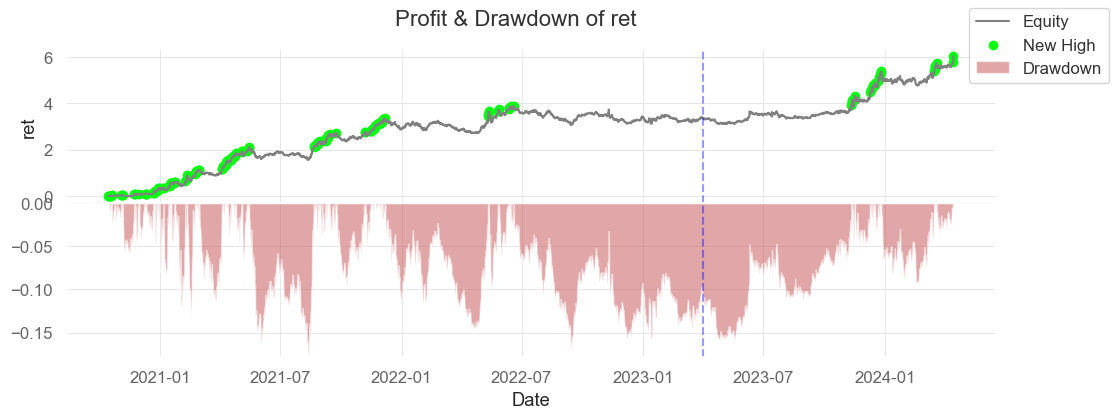

In [145]:
pp.plot_mdd(pd.DataFrame({'ret':(1+ret1).cumprod()-1}), 'ret', in_end, True)

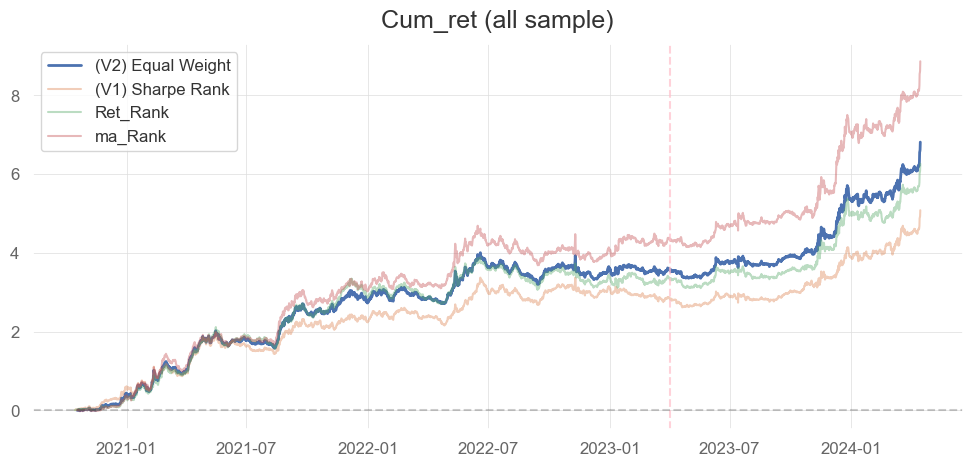

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( (1+ret_concat3[:]).cumprod()-1, label='(V2) Equal Weight', linewidth=2)
ax.plot( (1+ret1[:]).cumprod()-1, label='(V1) Sharpe Rank', alpha=0.4)
ax.plot( (1+ret2[:]).cumprod()-1, label='Ret_Rank', alpha=0.4)
ax.plot( (1+ret3[:]).cumprod()-1, label='ma_Rank', alpha=0.4)
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret (all sample)', fontsize=18, y=1.02)
plt.show()


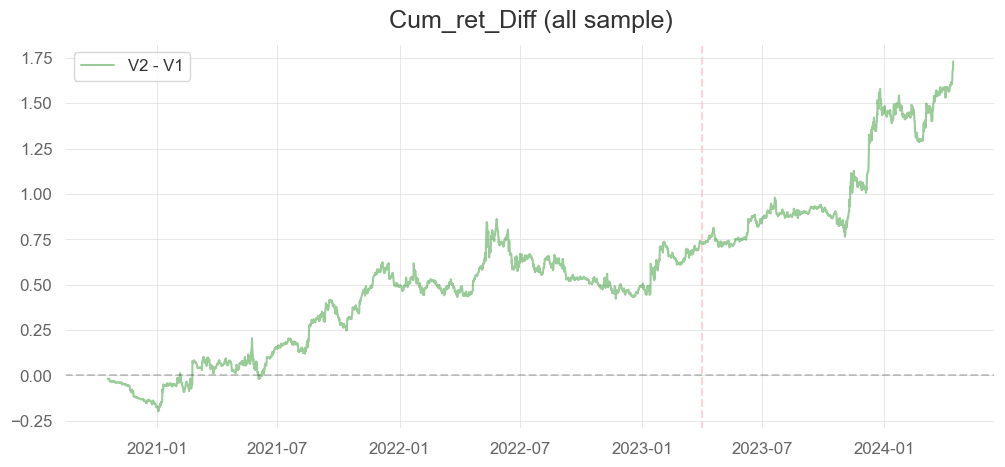

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( 
    ((1+ret_concat3[:]).cumprod()-1) - ((1+ret1[:]).cumprod()-1),
    label='V2 - V1', color='green', alpha=0.4
)
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret_Diff (all sample)', fontsize=18, y=1.02)
plt.show()

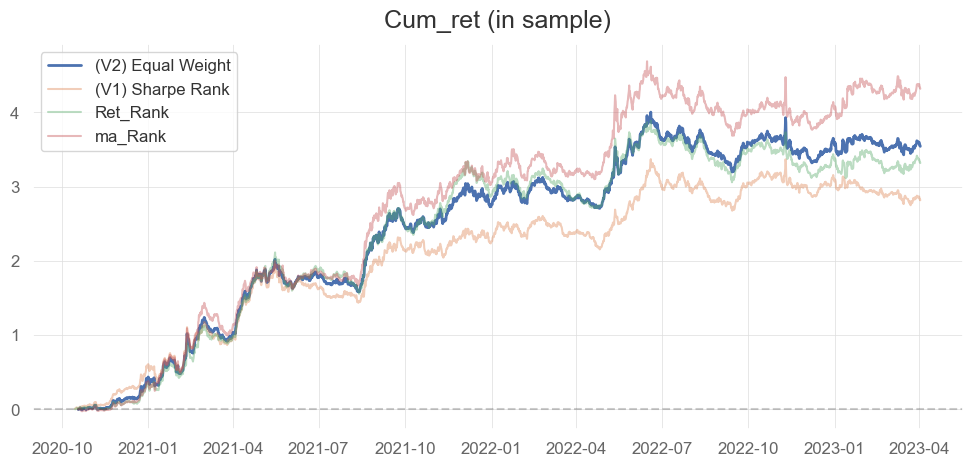

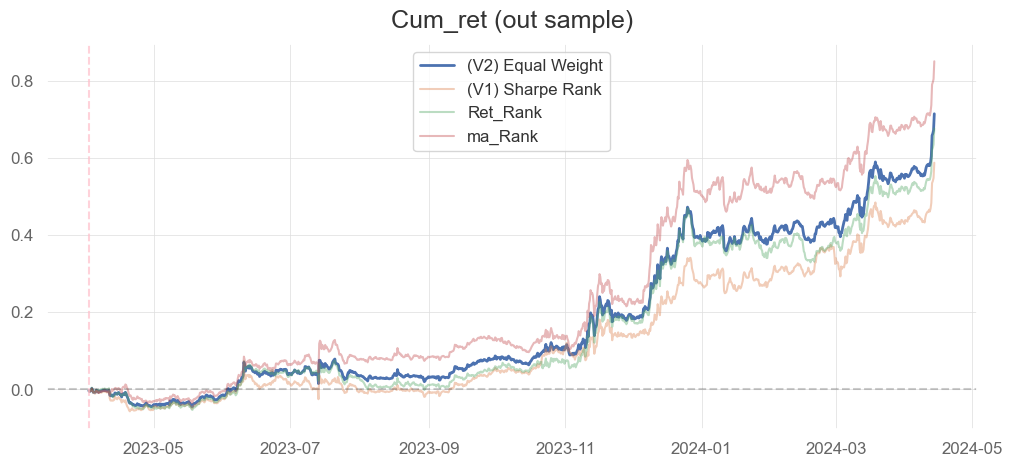

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( (1+ret_concat3[:in_end]).cumprod()-1, label='(V2) Equal Weight', linewidth=2)
ax.plot( (1+ret1[:in_end]).cumprod()-1, label='(V1) Sharpe Rank', alpha=0.4)
ax.plot( (1+ret2[:in_end]).cumprod()-1, label='Ret_Rank', alpha=0.4)
ax.plot( (1+ret3[:in_end]).cumprod()-1, label='ma_Rank', alpha=0.4)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret (in sample)', fontsize=18, y=1.02)
plt.show()



fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( (1+ret_concat3[in_end:]).cumprod()-1, label='(V2) Equal Weight', linewidth=2)
ax.plot( (1+ret1[in_end:]).cumprod()-1, label='(V1) Sharpe Rank', alpha=0.4)
ax.plot( (1+ret2[in_end:]).cumprod()-1, label='Ret_Rank', alpha=0.4)
ax.plot( (1+ret3[in_end:]).cumprod()-1, label='ma_Rank', alpha=0.4)
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret (out sample)', fontsize=18, y=1.02)
plt.show()


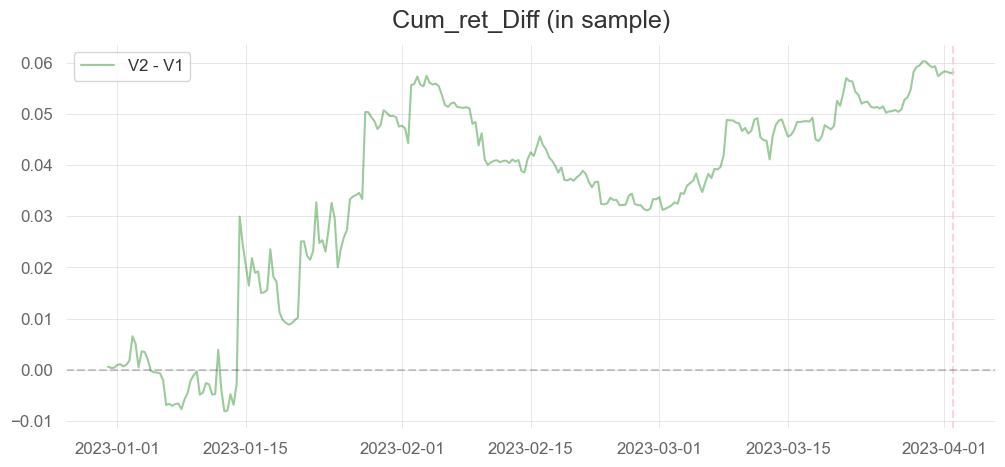

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( 
    ((1+ret_concat3['2022-12-31 00:00:00+0000':in_end]).cumprod()-1) - ((1+ret1['2022-12-31 00:00:00+0000':in_end]).cumprod()-1),
    label='V2 - V1', color='green', alpha=0.4
)
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret_Diff (in sample)', fontsize=18, y=1.02)
plt.show()

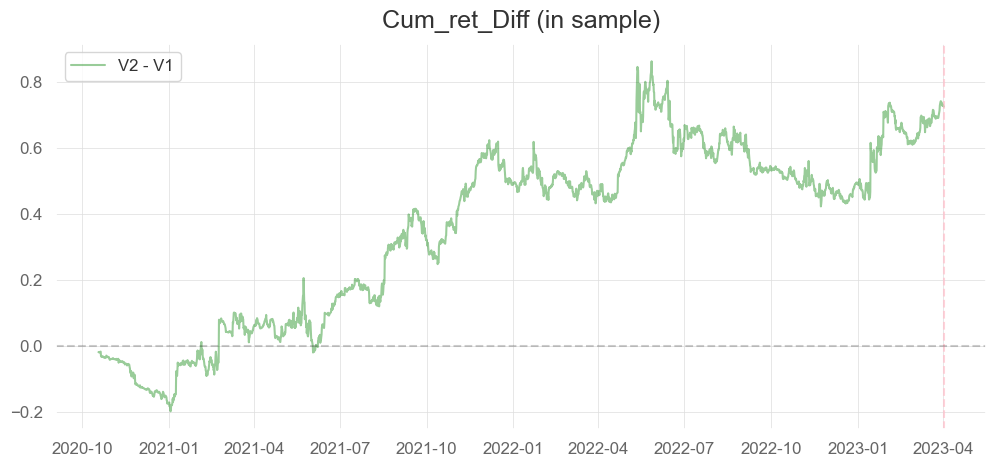

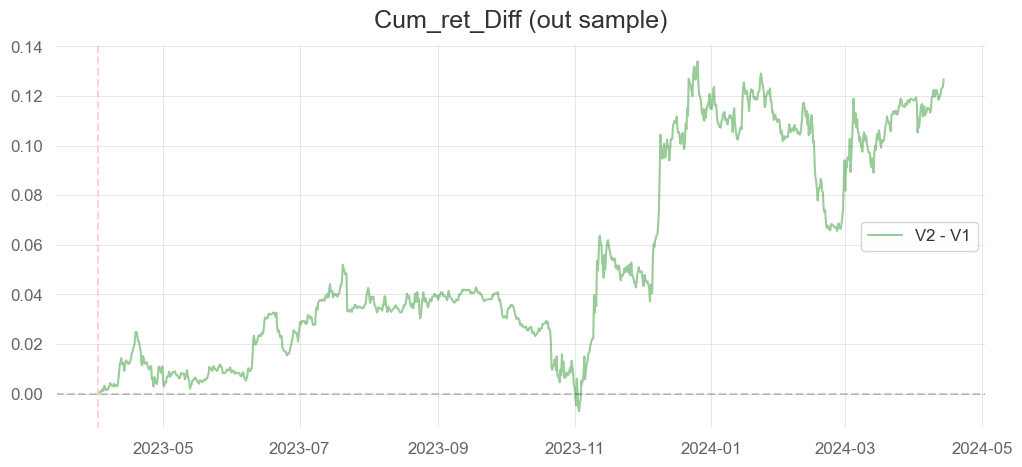

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( 
    ((1+ret_concat3[:in_end]).cumprod()-1) - ((1+ret1[:in_end]).cumprod()-1),
    label='V2 - V1', color='green', alpha=0.4
)
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret_Diff (in sample)', fontsize=18, y=1.02)
plt.show()


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( 
    ((1+ret_concat3[in_end:]).cumprod()-1) - ((1+ret1[in_end:]).cumprod()-1),
    label='V2 - V1', color='green', alpha=0.4
)
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret_Diff (out sample)', fontsize=18, y=1.02)
plt.show()



## Compare

In [33]:
ret_ori = get_ret_str(df_open, df_fr).sum(axis='columns')
ret_new = get_ret_str(df_open, df_fr, periods=choose_param).sum(axis='columns')

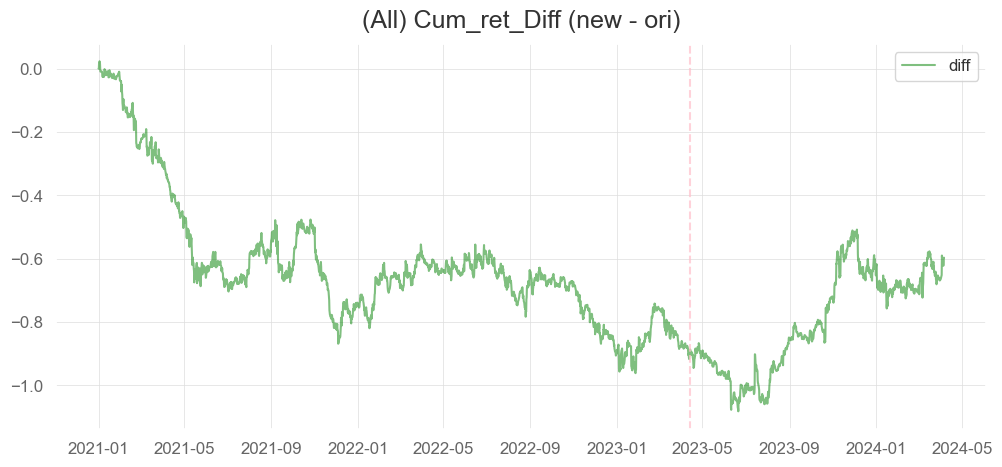

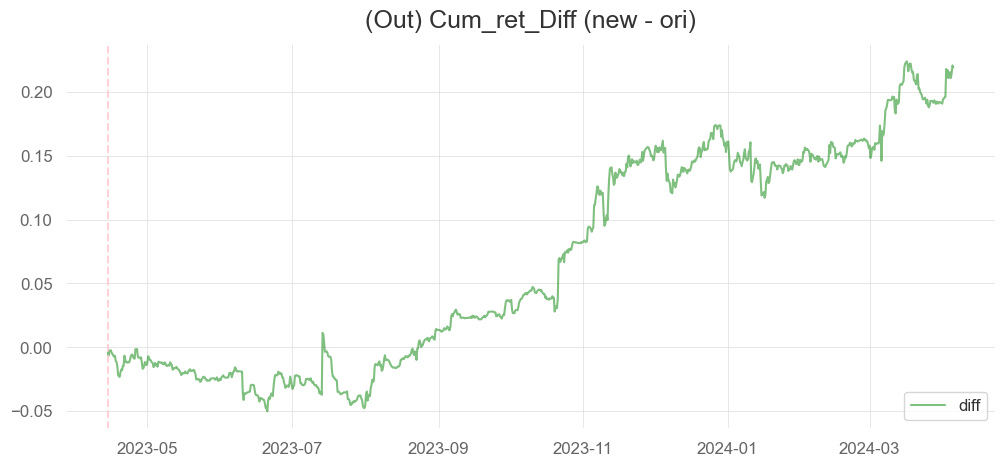

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( ((1+ret_new[start:]).cumprod()-1) - ((1+ret_ori[start:]).cumprod()-1), label='diff', c='green', alpha=0.5)
plt.legend()
plt.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
plt.title('(All) Cum_ret_Diff (new - ori)', fontsize=18, y=1.02)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( ((1+ret_new[in_end:]).cumprod()-1) - ((1+ret_ori[in_end:]).cumprod()-1), label='diff', c='green', alpha=0.5)
plt.legend()
plt.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
plt.title('(Out) Cum_ret_Diff (new - ori)', fontsize=18, y=1.02)
plt.show()

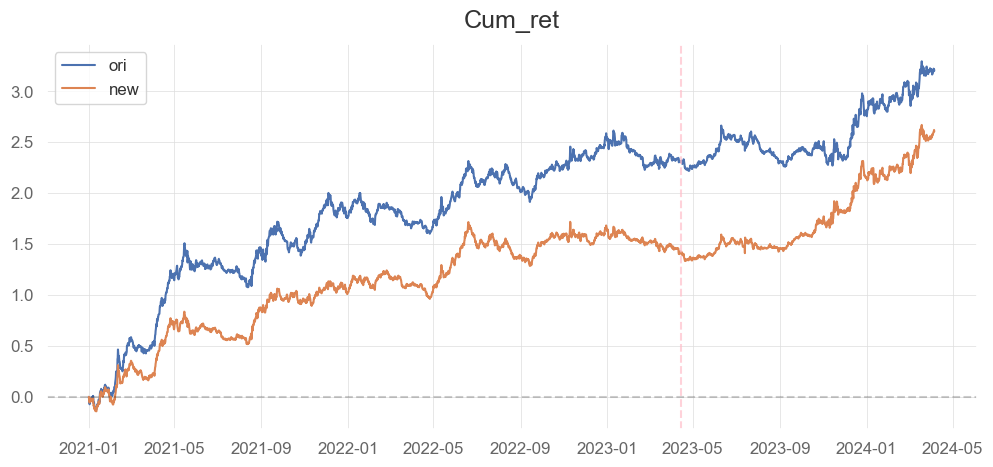

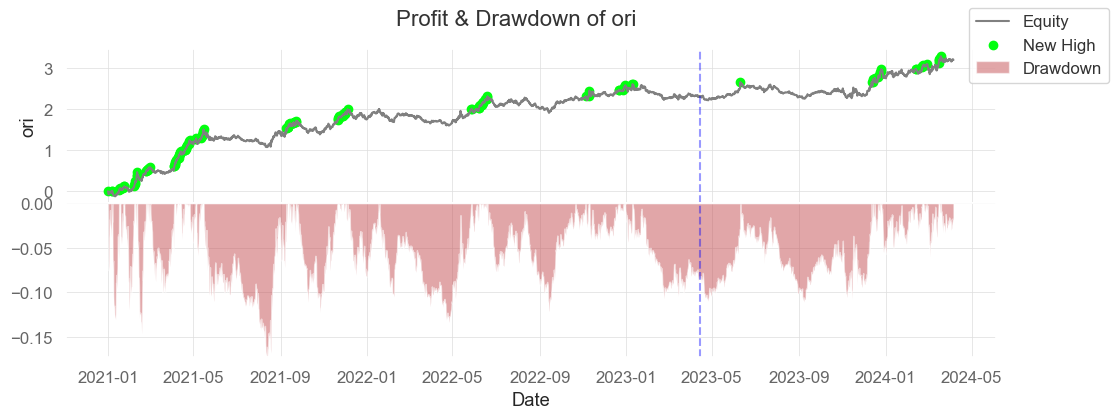

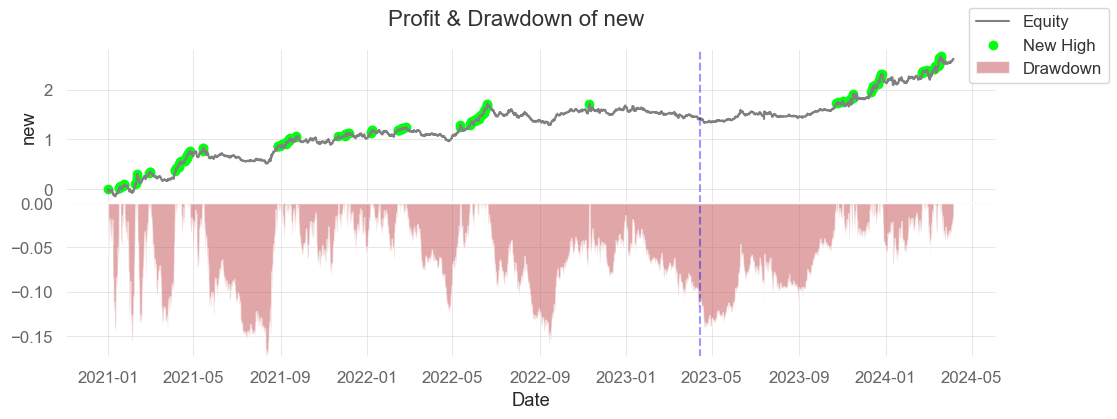

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( (1+ret_ori[start:]).cumprod()-1, label='ori')
ax.plot( (1+ret_new[start:]).cumprod()-1, label='new')
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret', fontsize=18, y=1.02)
plt.show()
pp.plot_mdd(pd.DataFrame({'ori':(1+ret_ori[start:]).cumprod()-1}), 'ori', separate_date=in_end)
pp.plot_mdd(pd.DataFrame({'new':(1+ret_new[start:]).cumprod()-1}), 'new', separate_date=in_end)


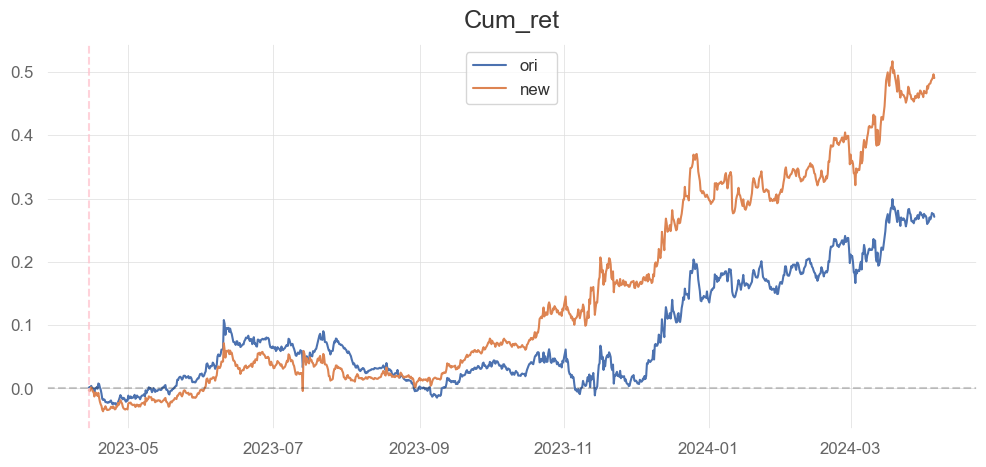

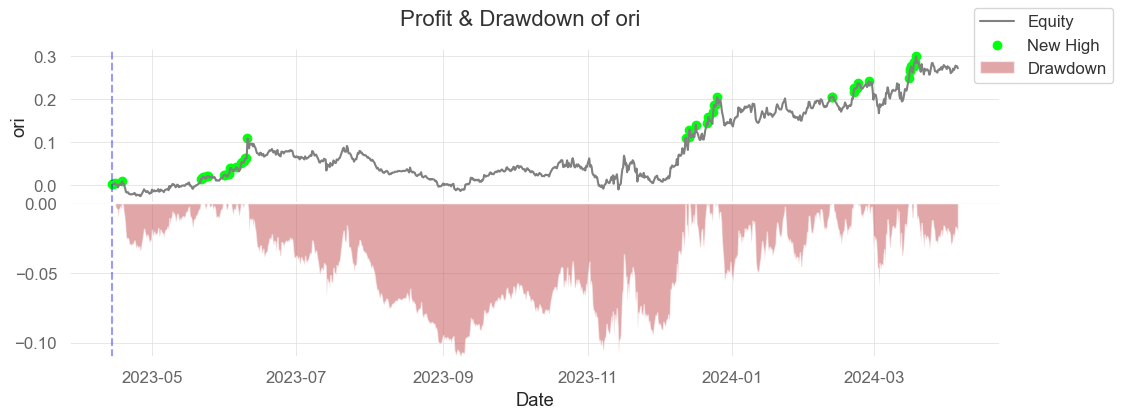

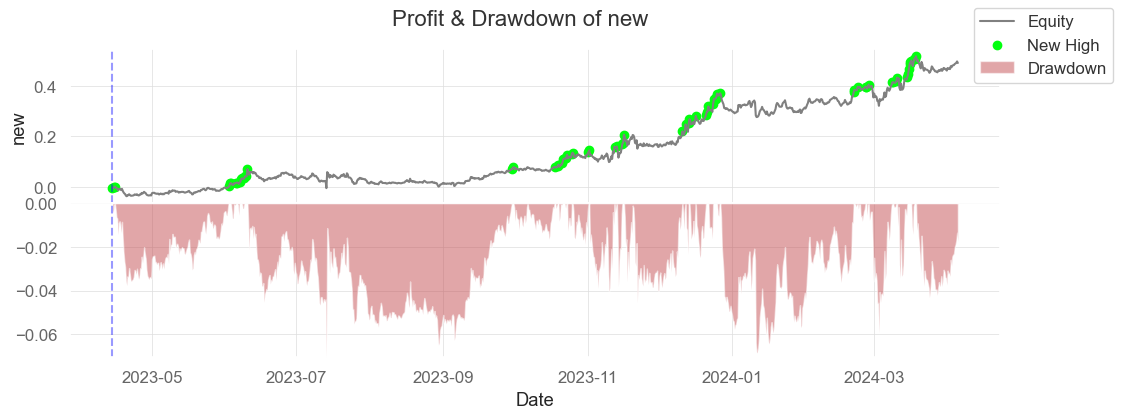

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot( (1+ret_ori[in_end:]).cumprod()-1, label='ori')
ax.plot( (1+ret_new[in_end:]).cumprod()-1, label='new')
ax.axvline(in_end, color='pink', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.legend()
plt.title('Cum_ret', fontsize=18, y=1.02)
plt.show()
pp.plot_mdd(pd.DataFrame({'ori':(1+ret_ori[in_end:]).cumprod()-1}), 'ori', separate_date=in_end)
pp.plot_mdd(pd.DataFrame({'new':(1+ret_new[in_end:]).cumprod()-1}), 'new', separate_date=in_end)


# Real Trade
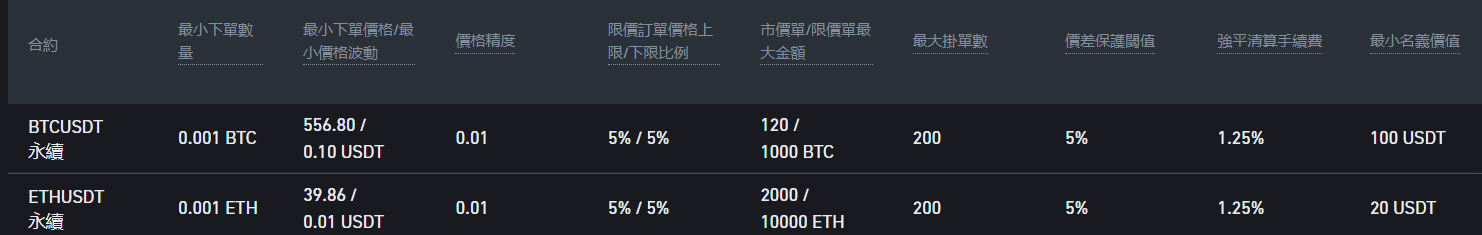
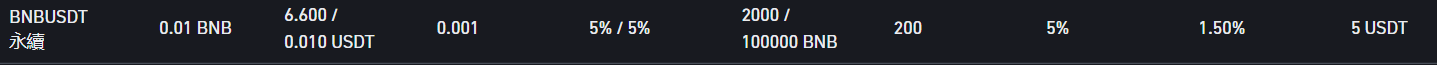
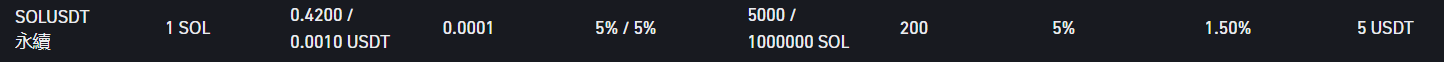
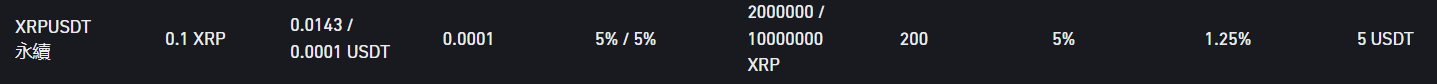
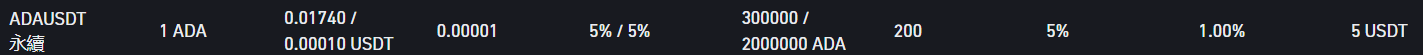
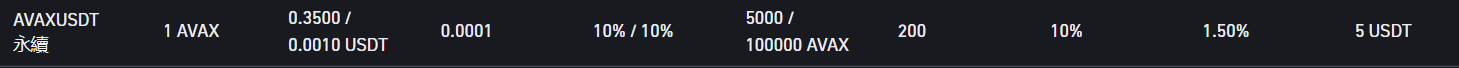
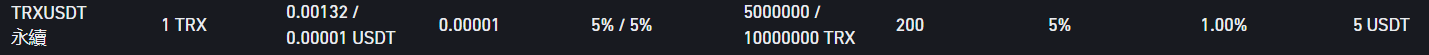
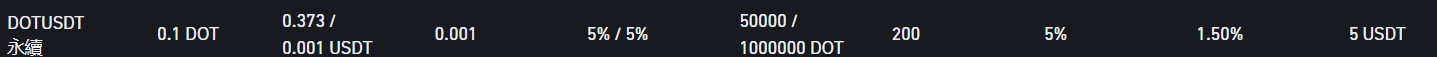
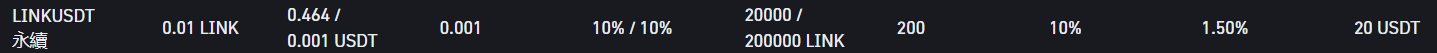


In [3]:
path_data_base = os.path.join(os.path.dirname(os.path.dirname(PROJECT_ROOT)), 'data_base')

symbol_list = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "SOLUSDT",
    "XRPUSDT",
    "ADAUSDT",
    "AVAXUSDT",
    "TRXUSDT",
    "DOTUSDT",
    "LINKUSDT",
]
df_open = pd.concat([
    pd.read_pickle(os.path.join(path_data_base, 'binance', 'usd', 'ohlcv', '1h', f"{symbol}_ohlcv.pkl"))[['open']]
    .rename(columns={'open': symbol})for symbol in symbol_list
], axis='columns').sort_index().ffill().dropna()

df_fr = pd.concat([
    pd.read_pickle(os.path.join(path_data_base, 'binance', 'usd', 'funding_rate', f"{symbol}_funding_rate.pkl"))[['funding_rate']]
    .rename(columns={'funding_rate': symbol})for symbol in symbol_list
], axis='columns').sort_index().ffill().dropna()

## Value Limit

In [7]:
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
hold = 8
annual_factor = 365.25


period_sharpe_rank = 51 
period_ret_rank = 64
period_ma_rank = 75

rets = open_timeframe.pct_change(fill_method=None).dropna()
weights = get_weights_sharpe_ret_ma(
    open_timeframe, rets, hold=hold,
    period_sharpe_rank=period_sharpe_rank, 
    period_ret_rank=period_ret_rank,
    ma2=period_ma_rank,
)
display(np.abs(weights[weights!=0].dropna()).describe())

print(f"max sol price: {int(df_open['SOLUSDT'].max())+1}")
print(f"min pos value: {int( ( int(df_open['SOLUSDT'].max())+1 ) / 0.041667 +1)} ")

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT
count,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000
mean,0.090137,0.095105,0.098717,0.098025,0.094834,0.095586,0.098838,0.098687,0.093901,0.095045
std,0.036324,0.035156,0.032825,0.033084,0.035156,0.034990,0.034009,0.033125,0.033909,0.034636
min,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667
25%,0.041667,0.041667,0.083333,0.083333,0.041667,0.083333,0.083333,0.083333,0.083333,0.083333
50%,0.083333,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.083333,0.125000
75%,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000
max,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000


max sol price: 259
min pos value: 6216 


## Track
* 順序
 * WILL2 -> ELIJAH2 -> KEVIN1 -> KEVIN2 -> WILL4

In [8]:
import matplotlib.pyplot as plt

In [34]:
# backtest
start = '2024-4-19 08:00:00 +0000'
timeframe = '8h'
hold = 8

param_sharpe = 51
param_ret = 64
param_ma = 75
limit = 16
open_timeframe = df_open.resample(timeframe).first().ffill()#.iloc[-76:]
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)#.iloc[-76:]

ret_v1 = get_ret_str(
        df_open=open_timeframe, fr=fr_timeframe, hold=hold, 
        period_sharpe_rank = param_sharpe,
        strategy = 'sharpe_rank',
    ).dropna()[start:].sum(axis='columns')

ret_v2 = get_ret_str(
        df_open=open_timeframe, fr=fr_timeframe, hold=hold, 
        period_sharpe_rank = param_sharpe,
        period_ret_rank = param_ret,
        ma2=param_ma,
        strategy='sharpe_ret_ma',
    ).dropna()[start:].sum(axis='columns')


wieght_v1 = get_weights_sharpe_rank(
        rets=open_timeframe.pct_change(fill_method=None), hold=hold, 
        periods = param_sharpe,
    )#[start:]

wieght_v2 = get_weights_sharpe_ret_ma(
        df_open=open_timeframe, rets=open_timeframe.pct_change(fill_method=None), hold=hold, 
        period_sharpe_rank = param_sharpe,
        period_ret_rank = param_ret,
        ma2=param_ma,
    )#[start:]


del timeframe, hold, param_sharpe, param_ret, param_ma, limit

In [42]:
ret1 = (wieght_v1.shift(1) * open_timeframe.pct_change()[start:]).dropna()
ret2 = (wieght_v2.shift(1) * open_timeframe.pct_change()[start:]).dropna()

display(ret1)
display(ret2)

display( (ret1 - np.abs(wieght_v1.diff().fillna(0)) * ( 0.0005 * (1+ret1) )).dropna() )        # fee 計在轉倉當下)
display( (ret2 - np.abs(wieght_v2.diff().fillna(0)) * ( 0.0005 * (1+ret2) )).dropna() )

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT
datetime,,,,,,,,,,
2024-04-19 08:00:00+00:00,0.002117,0.000805,0.000675,0.0,-0.0,0.000437,-0.001231,-0.001110,0.001180,0.002225
2024-04-19 16:00:00+00:00,-0.000197,-0.000132,0.001099,0.0,0.0,-0.004193,-0.000618,0.002240,-0.001620,-0.003264
2024-04-20 00:00:00+00:00,-0.001223,-0.000990,-0.001349,-0.0,-0.0,0.000928,0.002465,-0.000442,0.002279,0.000474


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT
datetime,,,,,,,,,,
2024-04-19 08:00:00+00:00,0.002117,0.000805,0.000675,0.0,-0.0,0.000437,-0.001231,-0.001110,0.001180,0.002225
2024-04-19 16:00:00+00:00,-0.000197,-0.000132,0.001099,0.0,0.0,-0.004193,-0.000618,0.002240,-0.001620,-0.003264
2024-04-20 00:00:00+00:00,-0.001223,-0.000990,-0.001349,-0.0,-0.0,0.000928,0.002465,-0.000442,0.002279,0.000474


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT
datetime,,,,,,,,,,
2024-04-19 08:00:00+00:00,0.002117,0.000805,0.000675,0.000000,-0.0,0.000437,-0.001231,-0.001110,0.001180,0.002225
2024-04-19 16:00:00+00:00,-0.000197,-0.000132,0.001099,0.000000,0.0,-0.004193,-0.000618,0.002240,-0.001620,-0.003264
2024-04-20 00:00:00+00:00,-0.001223,-0.000990,-0.001349,-0.000063,-0.0,0.000866,0.002465,-0.000442,0.002279,0.000474


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT
datetime,,,,,,,,,,
2024-04-19 08:00:00+00:00,0.002117,0.000805,0.000675,0.000000,-0.0,0.000437,-0.001231,-0.001110,0.001180,0.002225
2024-04-19 16:00:00+00:00,-0.000197,-0.000132,0.001099,0.000000,0.0,-0.004193,-0.000618,0.002240,-0.001620,-0.003264
2024-04-20 00:00:00+00:00,-0.001223,-0.000990,-0.001349,-0.000021,-0.0,0.000907,0.002465,-0.000442,0.002279,0.000474


In [ ]:
# real
timeframe = '8h'

df_sr = pd.read_pickle(os.path.join(path_data_base, 'trading_record', 'mbq', 'acount_info_2024-4-5.pkl'))
df_bal = pd.read_pickle(os.path.join(path_data_base, 'trading_record', 'mbq', 'balance_2024-4-5.pkl'))['2024':]
df_bal.index = pd.to_datetime(df_bal.index).tz_localize('UTC')
df_ti = pd.read_pickle(os.path.join(path_data_base, 'trading_record', 'mbq', 'trading_info_2024-4-5.pkl')).reset_index()
df_ti['datetime'] = pd.to_datetime(df_ti['datetime']).dt.tz_localize('UTC')
display(df_sr.columns)

pf = 'BINANCE_ELIJAH_MBQ2'
ret_real = df_bal[pf].resample(timeframe).first().pct_change(fill_method=None)[start:].fillna(0)

In [45]:
# non_abs
for side in ['BUY', 'SELL']:
    # print(side)
    for portfolio in ['BINANCE_WILL_MBQ2', 'BINANCE_WILL_MBQ4']:
        print(f"({side}) {portfolio}")
        temp = df_ti[(
            df_ti['portfolio']==portfolio) & (df_ti['side']==side
        )].set_index('datetime').sort_index().copy()
        temp.index = temp.index.round('1min')
        symbol_group = temp.groupby('symbol')
        df_slippage = pd.DataFrame({symbol: (temp[temp['symbol'] == symbol][:]['price'] / open[symbol] - 1).dropna().describe() for symbol in symbol_list})
        df_slippage.columns = [f"{col}" for col in df_slippage.columns]
        display(df_slippage)


(BUY) BINANCE_WILL_MBQ2


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,TRXUSDT
count,6.000000,21.000000,51.000000,28.000000,33.000000,33.000000,35.000000,35.000000,49.000000,37.000000
mean,0.000049,0.000047,0.000067,0.000182,0.000199,0.000089,0.000538,0.000070,-0.000022,0.000006
std,0.000206,0.000286,0.000224,0.000478,0.000498,0.000266,0.001275,0.000302,0.000259,0.000137
min,-0.000258,-0.000437,-0.000455,-0.001428,-0.000465,-0.000461,-0.001301,-0.000355,-0.000938,-0.000356
25%,0.000000,-0.000035,-0.000025,0.000076,0.000000,-0.000145,-0.000021,-0.000143,-0.000188,0.000000
50%,0.000005,0.000017,0.000048,0.000195,0.000000,0.000135,0.000019,0.000109,0.000000,0.000000
75%,0.000145,0.000120,0.000172,0.000303,0.000160,0.000159,0.000429,0.000196,0.000000,0.000080
max,0.000351,0.000763,0.000687,0.001650,0.002450,0.000765,0.003439,0.000829,0.000600,0.000214


(BUY) BINANCE_WILL_MBQ4


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,TRXUSDT
count,3.000000,5.000000,25.000000,9.000000,17.000000,19.000000,12.000000,6.000000,25.000000,16.000000
mean,-0.000529,-0.000033,-0.000110,0.000542,0.000181,0.000244,-0.000004,0.000387,0.000786,0.000051
std,0.000503,0.000263,0.000558,0.001841,0.000424,0.000581,0.000665,0.001184,0.001015,0.000194
min,-0.001000,-0.000247,-0.001227,-0.002088,-0.000320,-0.000469,-0.001193,-0.000352,-0.001011,-0.000427
25%,-0.000794,-0.000210,-0.000364,-0.000329,-0.000158,0.000000,-0.000231,-0.000163,-0.000104,0.000036
50%,-0.000587,-0.000114,-0.000066,-0.000027,0.000000,0.000146,0.000012,-0.000106,0.001572,0.000083
75%,-0.000294,0.000003,0.000000,0.001328,0.000483,0.000363,0.000402,0.000199,0.001614,0.000116
max,0.000000,0.000405,0.001425,0.004246,0.001163,0.001658,0.000892,0.002765,0.001878,0.000294


(SELL) BINANCE_WILL_MBQ2


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,TRXUSDT
count,8.000000,35.000000,56.000000,21.000000,40.000000,49.000000,20.000000,37.000000,50.000000,57.000000
mean,-0.000061,0.000041,0.000024,0.000272,-0.000048,-0.000129,-0.000047,-0.000011,-0.000137,-0.000017
std,0.000232,0.000226,0.000356,0.000542,0.000282,0.000437,0.000490,0.000329,0.000243,0.000144
min,-0.000595,-0.000228,-0.000611,-0.000627,-0.000771,-0.001580,-0.001507,-0.000609,-0.000853,-0.000335
25%,-0.000034,-0.000118,-0.000136,-0.000093,-0.000161,-0.000171,-0.000202,-0.000163,-0.000313,-0.000080
50%,-0.000002,-0.000022,-0.000018,0.000189,-0.000142,0.000000,-0.000083,-0.000052,-0.000107,0.000000
75%,0.000018,0.000064,0.000166,0.000331,0.000158,0.000000,0.000140,0.000059,0.000000,0.000000
max,0.000171,0.000745,0.001710,0.001579,0.000597,0.000418,0.000913,0.000896,0.000383,0.000682


(SELL) BINANCE_WILL_MBQ4


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,TRXUSDT
count,4.000000,10.000000,37.000000,6.000000,23.000000,26.000000,9.000000,6.000000,25.000000,24.000000
mean,-0.000056,0.000345,0.000157,0.000043,0.000044,-0.000352,0.000620,0.000061,0.000271,-0.000216
std,0.000121,0.000791,0.000696,0.000431,0.000851,0.000575,0.001351,0.000677,0.001076,0.000488
min,-0.000216,-0.000395,-0.000992,-0.000469,-0.001333,-0.001477,-0.000965,-0.000714,-0.000559,-0.001630
25%,-0.000086,-0.000157,-0.000132,-0.000247,-0.000426,-0.000559,0.000000,-0.000276,-0.000284,-0.000207
50%,-0.000042,0.000103,0.000000,-0.000031,-0.000157,-0.000272,0.000239,-0.000078,0.000000,-0.000082
75%,-0.000012,0.000521,0.000225,0.000324,0.000243,-0.000140,0.000772,0.000216,0.000000,0.000036
max,0.000078,0.002346,0.002697,0.000664,0.002929,0.001339,0.003066,0.001265,0.003423,0.000353


In [26]:
start = '2024-3-23 00:00:00 +0000'
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']
annual_factor = 365.25

display(pf)
display(pd.concat([
    bt.perf_table(get_daily_ret(ret_bt[start:end]*lev), annual_factor=annual_factor, is_compound=True, name='backtest'),
    bt.perf_table(get_daily_ret(ret_real[start:end]), annual_factor=annual_factor, is_compound=True, name='real'),
], axis='rows').set_index('name').T.round(3))

'BINANCE_WILL_MBQ4'

name,backtest,real
Total_Return(%),0.542,1.407
CAGR(%),15.138,43.976
Annnal_Sharpe,0.729,1.497
Annual_Vol,0.226,0.265
MDD(%),-2.634,-3.049
max_dd_period,-11.000,-11.000
Ret_to_Vol,0.024,0.053
Ret_to_MDD,0.206,0.461
CAGR_to_Vol,0.670,1.658
CAGR_to_MDD,5.748,14.423


In [24]:
start = '2024-3-23 00:00:00 +0000'
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']
annual_factor = 365.25

display(pf)
display(pd.concat([
    bt.perf_table(get_daily_ret(ret_bt[start:end]*lev), annual_factor=annual_factor, is_compound=True, name='backtest'),
    bt.perf_table(get_daily_ret(ret_real[start:end]), annual_factor=annual_factor, is_compound=True, name='real'),
], axis='rows').set_index('name').T.round(3))

'BINANCE_WILL_MBQ2'

name,backtest,real
Total_Return(%),0.947,1.270
CAGR(%),27.888,39.004
Annnal_Sharpe,0.753,0.929
Annual_Vol,0.452,0.460
MDD(%),-5.219,-5.086
max_dd_period,-11.000,-11.000
Ret_to_Vol,0.021,0.028
Ret_to_MDD,0.182,0.250
CAGR_to_Vol,0.617,0.847
CAGR_to_MDD,5.343,7.670


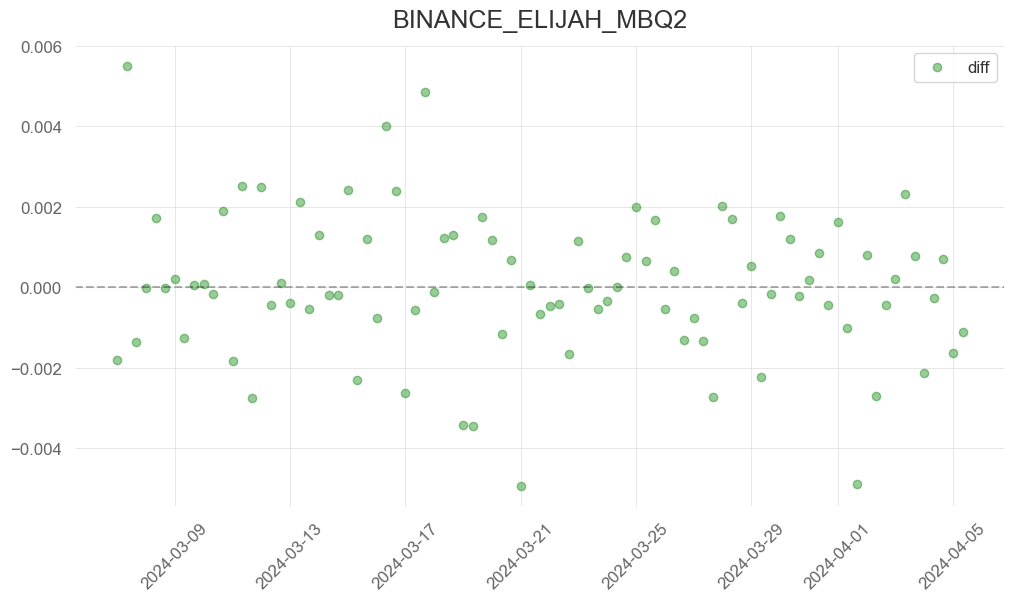

In [16]:
start = '2024-3-7 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']
diff = ret_real[start:end] - ret_bt[start:end]*lev
#diff = ret_real[start:end]/lev / ret_bt[start:end] - 1

fig, ax = plt.subplots(figsize=(12, 6))
plt.scatter(diff.index, diff, label='diff', color='green', alpha=0.4)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

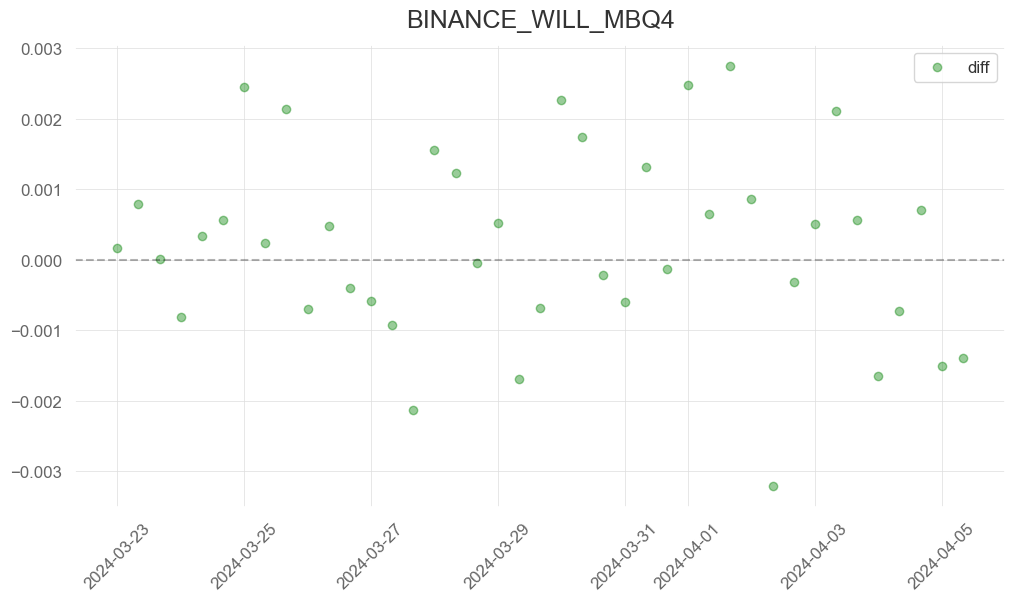

In [66]:
start = '2024-3-1 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']
diff = ret_real[start:end] - ret_bt[start:end]*lev
#diff = ret_real[start:end]/lev / ret_bt[start:end] - 1

fig, ax = plt.subplots(figsize=(12, 6))
plt.scatter(diff.index, diff, label='diff', color='green', alpha=0.4)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

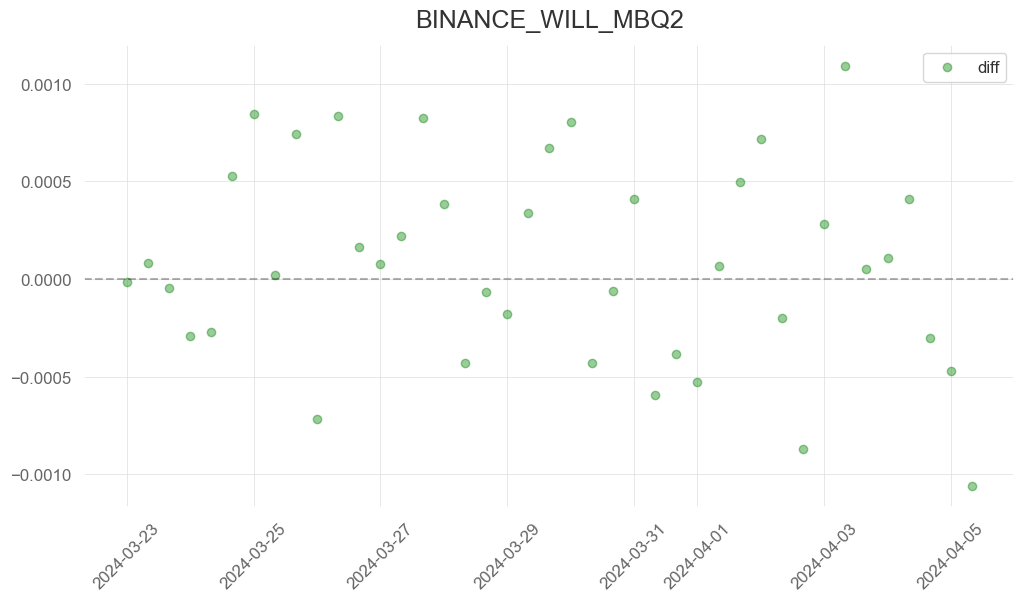

In [18]:
start = start = '2024-3-1 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']
diff = ret_real[start:end] - ret_bt[start:end]*lev
#diff = ret_real[start:end]/lev / ret_bt[start:end] - 1

fig, ax = plt.subplots(figsize=(12, 6))
plt.scatter(diff.index, diff, label='diff', color='green', alpha=0.4)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

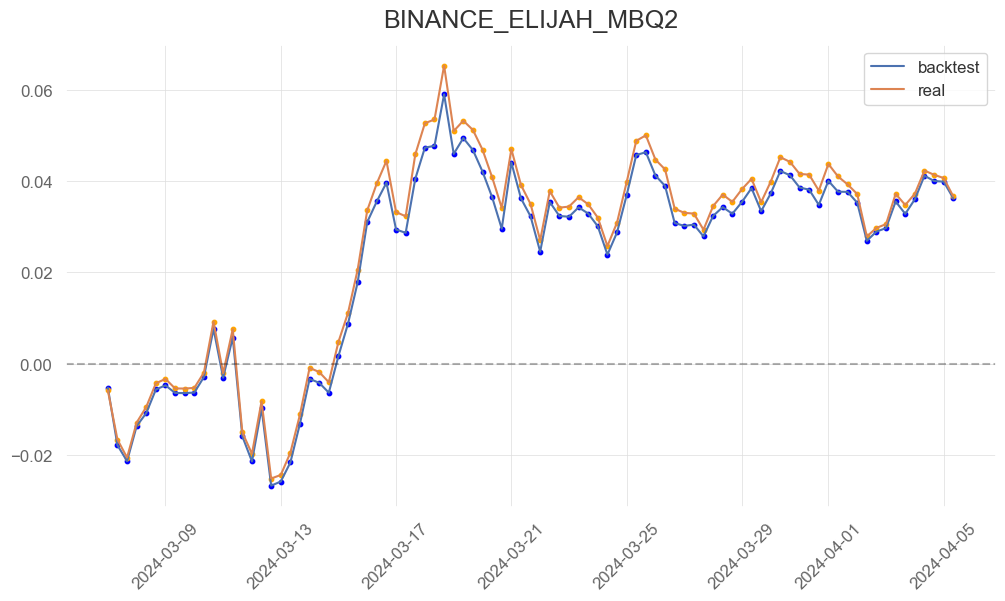

In [17]:
start = start = '2024-3-7 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1+ret_bt[start:end]).cumprod()-1, label='backtest')
ax.plot((1+ret_real[start:end]/lev).cumprod()-1, label='real')
ax.scatter(ret_bt[start:end].index, (1+ret_bt[start:end]).cumprod()-1, color='blue', s=10)  # Add scatter plot for backtest
ax.scatter(ret_real[start:end].index, (1+ret_real[start:end]/lev).cumprod()-1, color='orange', s=10)  # Add scatter plot for real

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

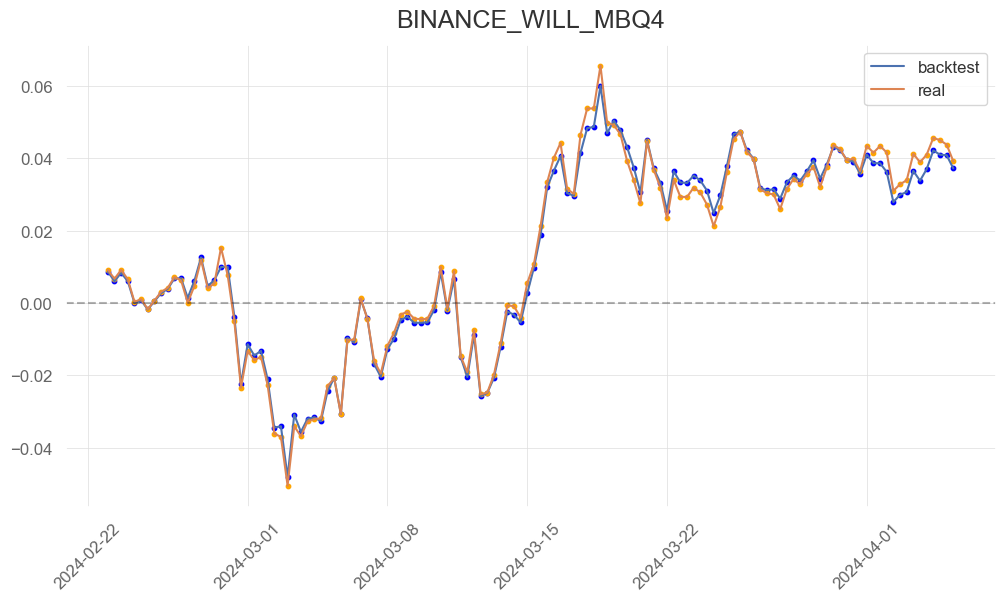

In [13]:
start = start = '2024-2-23 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1+ret_bt[start:end]).cumprod()-1, label='backtest')
ax.plot((1+ret_real[start:end]/lev).cumprod()-1, label='real')
ax.scatter(ret_bt[start:end].index, (1+ret_bt[start:end]).cumprod()-1, color='blue', s=10)  # Add scatter plot for backtest
ax.scatter(ret_real[start:end].index, (1+ret_real[start:end]/lev).cumprod()-1, color='orange', s=10)  # Add scatter plot for real

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

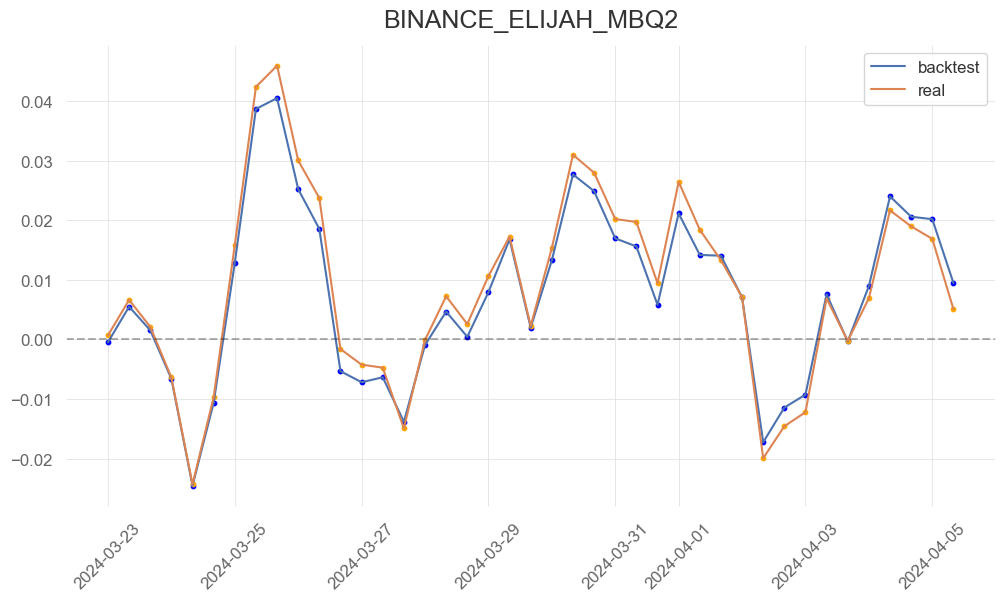

In [18]:
start = start = '2024-3-23 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1+ret_bt[start:end]*lev).cumprod()-1, label='backtest')
ax.plot((1+ret_real[start:end]).cumprod()-1, label='real')
ax.scatter(ret_bt[start:end].index, (1+ret_bt[start:end]*lev).cumprod()-1, color='blue', s=10)  # Add scatter plot for backtest
ax.scatter(ret_real[start:end].index, (1+ret_real[start:end]).cumprod()-1, color='orange', s=10)  # Add scatter plot for real

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

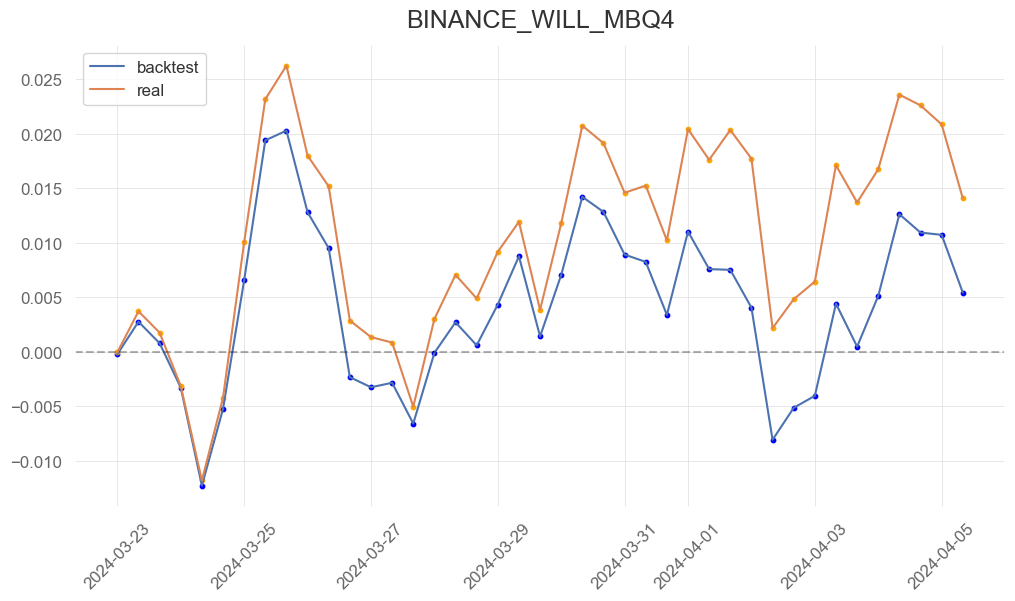

In [14]:
start = start = '2024-3-23 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1+ret_bt[start:end]*lev).cumprod()-1, label='backtest')
ax.plot((1+ret_real[start:end]).cumprod()-1, label='real')
ax.scatter(ret_bt[start:end].index, (1+ret_bt[start:end]*lev).cumprod()-1, color='blue', s=10)  # Add scatter plot for backtest
ax.scatter(ret_real[start:end].index, (1+ret_real[start:end]).cumprod()-1, color='orange', s=10)  # Add scatter plot for real

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

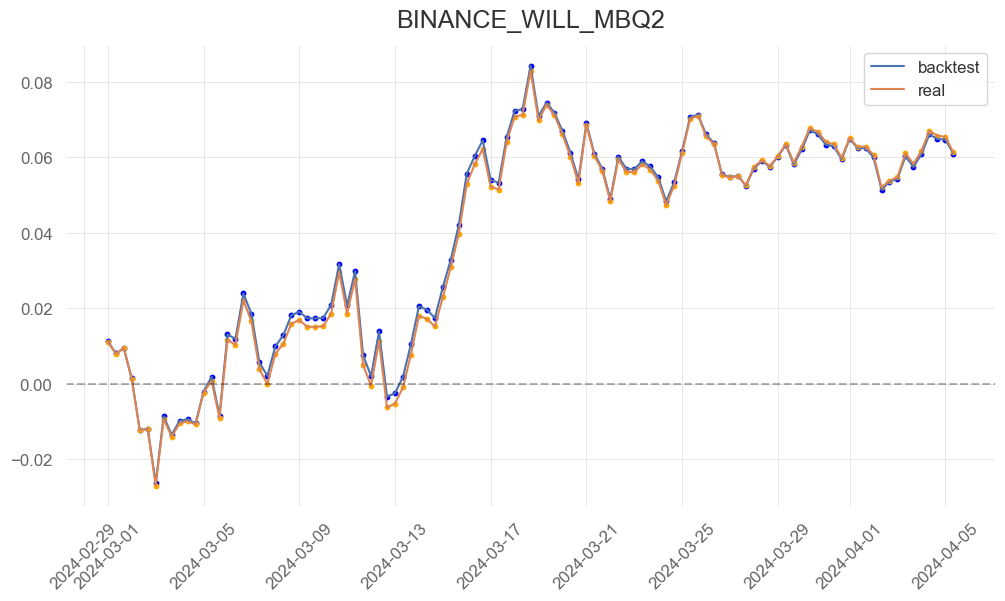

In [143]:
start = start = '2024-3-1 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1+ret_bt[start:end]).cumprod()-1, label='backtest')
ax.plot((1+ret_real[start:end]/lev).cumprod()-1, label='real')
ax.scatter(ret_bt[start:end].index, (1+ret_bt[start:end]).cumprod()-1, color='blue', s=10)  # Add scatter plot for backtest
ax.scatter(ret_real[start:end].index, (1+ret_real[start:end]/lev).cumprod()-1, color='orange', s=10)  # Add scatter plot for real

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

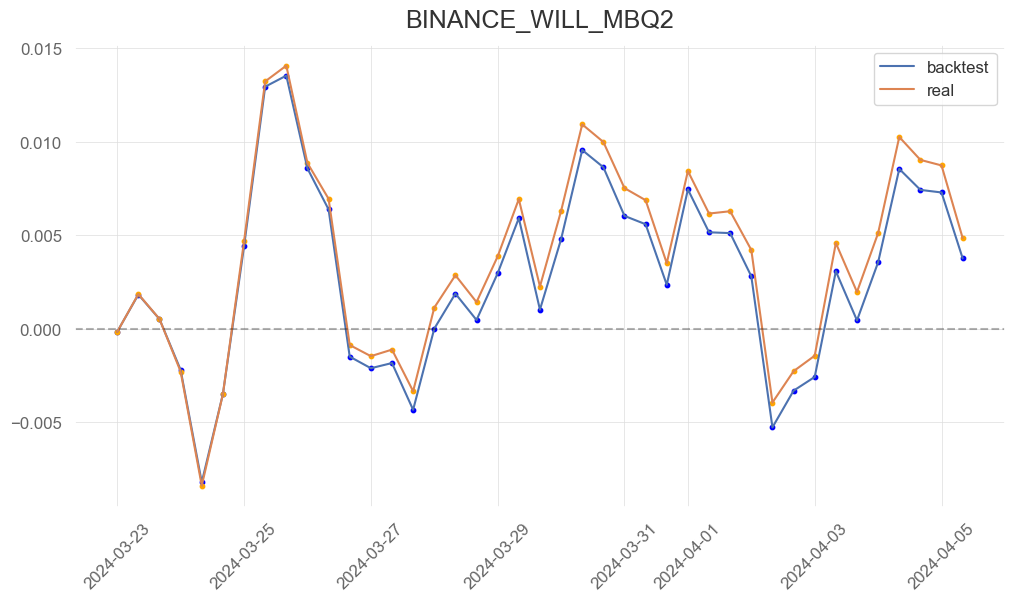

In [110]:
start = start = '2024-3-23 00:00:00 +0000'#ret_bt.index[0]
end = ret_bt.index[-1]
lev = df_sr[pf].loc['leverage']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1+ret_bt[start:end]).cumprod()-1, label='backtest')
ax.plot((1+ret_real[start:end]/lev).cumprod()-1, label='real')
ax.scatter(ret_bt[start:end].index, (1+ret_bt[start:end]).cumprod()-1, color='blue', s=10)  # Add scatter plot for backtest
ax.scatter(ret_real[start:end].index, (1+ret_real[start:end]/lev).cumprod()-1, color='orange', s=10)  # Add scatter plot for real

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.title(pf, fontsize=18, y=1.02)
plt.show()

## Weelky Report
* TODO
    * 利用 AUM 加權平均 ret 來呈現 (各帳戶各自槓桿)
    * 調整回無槓桿 (1倍) 

In [ ]:
def get_db_df(
        collection_name, db_name='PDATA', mongo=mongo, 
        need_col=None, query_dict=None, sort_name=None,
        limit=0,
    ):
    collection = mongo[db_name][collection_name]
    # filter
    projection_dict = {'_id': 0}
    projection_dict.update({col: 1 for col in need_col}) if need_col else None
    query = collection.find(query_dict, projection_dict)
    # sort
    query = query.sort(sort_name, -1) if sort_name else query
    data = query.limit(limit)
    df = pd.DataFrame(list(data))
    return df

In [ ]:
# Get daily index to reindex non-daily data
tsx = get_db_df(
    collection_name = 'index', db_name='PDATA',
    need_col = ['日期', '指數碼', '指數收盤價'],
    query_dict = {
        '日期': {'$gte': pd.to_datetime(start_date)},
        '指數碼': 'IX0001'
    },
)
tsx = tsx.rename(columns={'日期': 'datetime'})
tsx = tsx.sort_values(by='datetime')

In [5]:
timeframe = '8h'
open_timeframe = df_open.resample(timeframe).first().ffill()
fr_timeframe = df_fr.resample(timeframe).sum().fillna(0)
annual_factor = 365.25

hold = 8
period_sharpe_rank = 51 
period_ret_rank = 64
ma1, ma2 = 1, 75
max_param = max(period_sharpe_rank, period_ret_rank)
max_param2 = max(period_sharpe_rank, period_ret_rank, ma2)

# ret_rank
ret1 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    periods = period_sharpe_rank,
    hold = hold,
    strategy = 'sharpe_rank'
).sum(axis='columns').iloc[max_param+2:]

# sharpe_rank
ret2 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    periods = period_ret_rank,
    hold = hold,
    strategy = 'ret_rank'
).sum(axis='columns').iloc[max_param+2:]

## concat -> 改調整權重進行
# ret = pd.concat([ret1, ret2], axis='columns').fillna(0).mean(axis='columns').sort_index()

# Equal Weight
ret = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    hold=hold,
    period_sharpe_rank=period_sharpe_rank, 
    period_ret_rank=period_ret_rank,
    strategy = 'sharpe_ret',
).sum(axis='columns').iloc[max_param+2:]


ret3 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    ma1=ma1, ma2=ma2,
    hold = 8,
    strategy = 'ma_rank'
).dropna().sum(axis='columns')



ret_concat3 = get_ret_str(
    df_open = open_timeframe,
    fr = fr_timeframe,
    hold=hold,
    period_sharpe_rank=period_sharpe_rank, 
    period_ret_rank=period_ret_rank,
    ma1=ma1, ma2=ma2,
    strategy = 'sharpe_ret_ma',
).sum(axis='columns').iloc[max_param2+2:]

In [20]:
ret = df_bal.sum(axis='columns').pct_change(fill_method=None)['2024-3-23':]

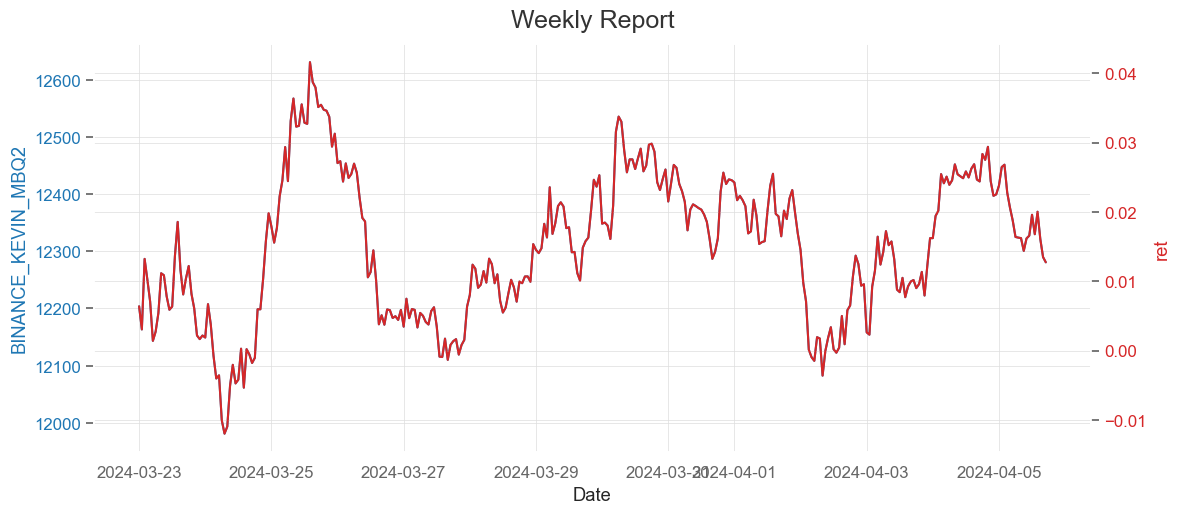

In [21]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('BINANCE_KEVIN_MBQ2', color=color)
ax1.plot(df_bal.sum(axis='columns')['2024-3-23':], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('ret', color=color)  # we already handled the x-label with ax1
ax2.plot((1+ret['2024-3-23':]).cumprod()-1, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Weekly Report', fontsize=18, y=1.02)
plt.show()

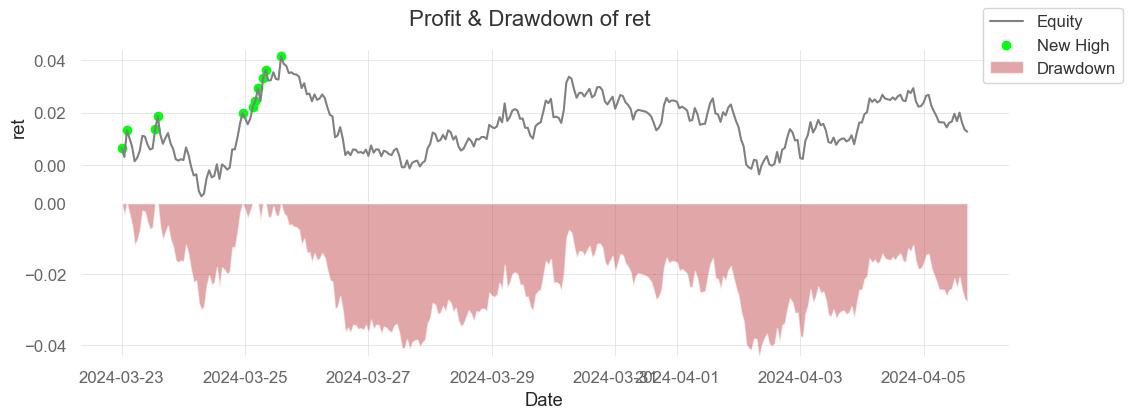

In [29]:
pp.plot_mdd(pd.DataFrame({'ret':(1+ret).cumprod()-1}), 'ret', separate_date=None)

In [28]:
bt.perf_table((1+ret['2024-3-23':]).resample('D').prod()-1, annual_factor=365.25, is_compound=True).round(3).T

,0
name,None
Total_Return(%),1.273
CAGR(%),39.088
Annnal_Sharpe,1.705
Annual_Vol,0.205
MDD(%),-2.465
max_dd_period,-11
Ret_to_Vol,0.062
Ret_to_MDD,0.516
CAGR_to_Vol,1.906


## VaR

In [34]:
from scipy.stats import norm

ret_daily = (1+ret['2024-3-23':]).resample('D').prod()-1
u = ret_daily.mean()
σ2 = ret_daily.var()
σ  = ret_daily.std()

confidence = 0.95
Z_05 = -norm.ppf(confidence)
print(Z_05*σ - u)

-0.0186089203792246


# Tail